In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.patches as patches
import time
from numba import jit,njit,prange
from IPython.core.display import display, HTML
from matplotlib.animation import FuncAnimation
from tqdm.notebook import tqdm

display(HTML("<style>.container {width: 95% !important; }</style>"))

%matplotlib notebook

In [2]:
@njit(fastmath=True)
def extrapolate_4th(x1,x2,x3,x4):
    return 4*x1-6*x2+4*x3-x4

In [3]:
@njit(fastmath=True)
def extrapolate_3rd(x1,x2,x3):
    return 3*x1-3*x2+x3

In [4]:
@njit(fastmath=True)
def face_interpolate_4th(x1,x2,x3,x4):
    return (-x1+9*x2+9*x3-x4)/16

In [5]:
@njit(fastmath=True)
def diff_interpolate_4th(x1,x2,x3,x4,h):
    #h denotes grid spacing
    return (x1-27*x2+27*x3-x4)/(24*h)

In [6]:
@njit(fastmath=True)
def p_face(Ny,Nx,square_coord,P):
    
    N=Nx*Ny
    n_squares=square_coord.shape[1] 
    
    Pxf=np.zeros((Ny,Nx+1))
    Pyf=np.zeros((Ny+1,Nx))
    
    #horizontal faces
    for j in range(Ny):
        i=0
        
        PP=P[j][i]
        PE=P[j][i+1]
        Pxf[j][i]=1.5*PP-0.5*PE
        
        for i in range(1,Nx):
            PP=P[j][i-1]
            PE=P[j][i]
            Pxf[j][i]=0.5*(PP+PE)
            
        i=Nx
        
        PP=P[j][i-1]
        PW=P[j][i-2]
        Pxf[j][i]=1.5*PP-0.5*PW

    #vertical faces
    for i in range(Nx):
        j=0
        PP=P[j][i]
        PN=P[j+1][i]
        Pyf[j][i]=1.5*PP-0.5*PN
        
        j=Ny
        PP=P[j-1][i]
        PS=P[j-2][i]
        Pyf[j][i]=1.5*PP-0.5*PS
        
    for j in range(1,Ny):
        for i in range(Nx):
            PP=P[j-1][i]
            PN=P[j][i]
            Pyf[j][i]=0.5*(PP+PN)
        
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        #left and right square
        for j in range(Ny_btm,Ny_top):
            i=Nx_lft
            
            PP=P[j][i-1]
            PW=P[j][i-2]
            
            Pxf[j][i]=1.5*PP-0.5*PW
            
            i=Nx_rgt
            
            PP=P[j][i]
            PE=P[j][i+1]
            
            Pxf[j][i]=1.5*PP-0.5*PE
            
        #top and bottom square
        for i in range(Nx_lft,Nx_rgt):
            j=Ny_btm
            
            PP=P[j-1][i]
            PS=P[j-2][i]
            
            Pyf[j][i]=1.5*PP-0.5*PS
            
            j=Ny_top
            PP=P[j][i]
            PN=P[j+1][i]
            
            Pyf[j][i]=1.5*PP-0.5*PN
            
    return Pxf,Pyf

In [7]:
@njit(fastmath=True)
def face(Ny,Nx,square_coord,phi,inlet):
    
    N=Nx*Ny
    n_squares=square_coord.shape[1] 
    
    phi_xf=np.zeros((Ny,Nx+1))
    phi_yf=np.zeros((Ny+1,Nx))
    
    #horizontal faces
    for j in range(Ny):
        i=0
        
        phi_xf[j][i]=inlet[j]
        
        for i in range(1,Nx):
            phi_P=phi[j][i-1]
            phi_E=phi[j][i]
            phi_xf[j][i]=0.5*(phi_P+phi_E)
            
        i=Nx
        
        phi_P=phi[j][i-1]
        phi_W=phi[j][i-2]
        phi_xf[j][i]=1.5*phi_P-0.5*phi_W

    #vertical faces
    for i in range(Nx):
        j=0
        phi_P=phi[j][i]
        phi_N=phi[j+1][i]
        phi_yf[j][i]=1.5*phi_P-0.5*phi_N
        
        j=Ny
        phi_P=phi[j-1][i]
        phi_S=phi[j-2][i]
        phi_yf[j][i]=1.5*phi_P-0.5*phi_S
        
    for j in range(1,Ny):
        for i in range(Nx):
            phi_P=phi[j-1][i]
            phi_N=phi[j][i]
            phi_yf[j][i]=0.5*(phi_P+phi_N)
        
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        #left and right square
        for j in range(Ny_btm,Ny_top):
            i=Nx_lft
            
            phi_P=phi[j][i-1]
            phi_W=phi[j][i-2]
            
            phi_xf[j][i]=1.5*phi_P-0.5*phi_W
            
            i=Nx_rgt
            
            phi_P=phi[j][i]
            phi_E=phi[j][i+1]
            
            phi_xf[j][i]=1.5*phi_P-0.5*phi_E
            
        #top and bottom square
        for i in range(Nx_lft,Nx_rgt):
            j=Ny_btm
            
            phi_P=phi[j-1][i]
            phi_S=phi[j-2][i]
            
            phi_yf[j][i]=1.5*phi_P-0.5*phi_S
            
            j=Ny_top
            phi_P=phi[j][i]
            phi_N=phi[j+1][i]
            
            phi_yf[j][i]=1.5*phi_P-0.5*phi_N
            
    return phi_xf,phi_yf

In [8]:
@njit(fastmath=True)
def upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,vs,phi_e,phi_w,phi_n,phi_s,phi_S,phi_W,phi_P,phi_E,phi_N,dy,dx,v):
    BP=0
    
    ue_abs=dy*(np.abs(ue)+ue)
    AP+=ue_abs
    BP-=ue_abs*(phi_e-phi_P)
    
    ue_abs=dy*(np.abs(ue)-ue)
    AE-=ue_abs
    BP+=ue_abs*(phi_e-phi_E)

    uw_abs=dy*(np.abs(uw)-uw)
    AP+=uw_abs
    BP-=uw_abs*(phi_w-phi_P)

    uw_abs=dy*(np.abs(uw)+uw)
    AW-=uw_abs
    BP+=uw_abs*(phi_w-phi_W)
    
    vn_abs=dx*(np.abs(vn)+vn)
    AP+=vn_abs
    BP-=vn_abs*(phi_n-phi_P)
    
    vn_abs=dx*(np.abs(vn)-vn)
    AN-=vn_abs
    BP+=vn_abs*(phi_n-phi_N)
        
    vs_abs=dx*(np.abs(vs)-vs)
    AP+=vs_abs
    BP-=vs_abs*(phi_s-phi_P)
        
    vs_abs=dx*(np.abs(vs)+vs)
    AS-=vs_abs
    BP+=vs_abs*(phi_s-phi_S)
        
    return AE,AW,AN,AS,AP,BP

In [9]:
@njit     
def QUICK3(AE,AW,AN,AS,AP,ue,uw,vn,vs,phi_S,phi_W,phi_P,phi_E,phi_N,dy,dx,v):
    BP=0
    phi_EE=extrapolate_3rd(phi_E,phi_P,phi_W)
    phi_WW=extrapolate_3rd(phi_W,phi_P,phi_E)
    phi_NN=extrapolate_3rd(phi_N,phi_P,phi_S)
    phi_SS=extrapolate_3rd(phi_S,phi_P,phi_N)
        
    AP+=dy*(abs(ue)+ue)
    BP-=(abs(ue)+ue)*dy*(3*phi_E-2*phi_P-phi_W)/8
    
    AE-=dy*(abs(ue)-ue)
    BP+=dy*(abs(ue)-ue)*(3*phi_P-2*phi_E-phi_EE)/8

    AP+=dy*(abs(uw)-uw)
    BP-=dy*(abs(uw)-uw)*(3*phi_W-2*phi_P-phi_E)/8

    AW-=dy*(abs(uw)+uw)
    BP+=dy*(abs(uw)+uw)*(3*phi_P-2*phi_W-phi_WW)/8
    
    AP+=dx*(abs(vn)+vn)
    BP-=dx*(abs(vn)+vn)*(3*phi_N-2*phi_P-phi_S)/8
    
    AN-=dx*(abs(vn)-vn)
    BP+=dx*(abs(vn)-vn)*(3*phi_P-2*phi_N-phi_NN)/8
        
    AP+=dx*(abs(vs)-vs)
    BP-=dx*(abs(vs)-vs)*(3*phi_S-2*phi_P-phi_N)/8
        
    AS-=dx*(abs(vs)+vs)
    BP+=dx*(abs(vs)+vs)*(3*phi_P-2*phi_S-phi_SS)/8
    
    return AE,AW,AN,AS,AP,BP

In [10]:
@njit     
def QUICK3_limited(AE,AW,AN,AS,AP,ue,uw,vn,vs,phi_S,phi_W,phi_P,phi_E,phi_N,dy,dx,v):
    BP=0
    
    phi_EE=extrapolate_3rd(phi_E,phi_W,phi_P)
    phi_WW=extrapolate_3rd(phi_W,phi_P,phi_E)
    phi_NN=extrapolate_3rd(phi_N,phi_P,phi_S)
    phi_SS=extrapolate_3rd(phi_S,phi_P,phi_N)
    
    limit=limiter(phi_E,phi_P,phi_W)
    AP+=dy*(abs(ue)+ue)
    BP-=(abs(ue)+ue)*limit*dy*(3*phi_E-2*phi_P-phi_W)/8
    
    limit=limiter(phi_P,phi_E,phi_EE)
    AE-=dy*(abs(ue)-ue)
    BP+=dy*(abs(ue)-ue)*limit*(3*phi_P-2*phi_E-phi_EE)/8

    limit=limiter(phi_W,phi_P,phi_E)
    AP+=dy*(abs(uw)-uw)
    BP-=dy*(abs(uw)-uw)*limit*(3*phi_W-2*phi_P-phi_E)/8

    limit=limiter(phi_P,phi_W,phi_WW)
    AW-=dy*(abs(uw)+uw)
    BP+=dy*(abs(uw)+uw)*limit*(3*phi_P-2*phi_W-phi_WW)/8
    
    limit=limiter(phi_N,phi_P,phi_S)
    AP+=dx*(abs(vn)+vn)
    BP-=dx*(abs(vn)+vn)*limit*(3*phi_N-2*phi_P-phi_S)/8
    
    limit=limiter(phi_P,phi_N,phi_NN)
    AN-=dx*(abs(vn)-vn)
    BP+=dx*(abs(vn)-vn)*limit*(3*phi_P-2*phi_N-phi_NN)/8
        
    limit=limiter(phi_S,phi_P,phi_N)
    AP+=dx*(abs(vs)-vs)
    BP-=dx*(abs(vs)-vs)*limit*(3*phi_S-2*phi_P-phi_N)/8
        
    limit=limiter(phi_P,phi_S,phi_SS)
    AS-=dx*(abs(vs)+vs)
    BP+=dx*(abs(vs)+vs)*limit*(3*phi_P-2*phi_S-phi_SS)/8
    
    return AE,AW,AN,AS,AP,BP

In [11]:
@njit(fastmath=True)
def upwind_DC_limited(AE,AW,AN,AS,AP,ue,uw,vn,vs,phi_e,phi_w,phi_n,phi_s,phi_S,phi_W,phi_P,phi_E,phi_N,dy,dx,v):
    BP=0
    
    phi_EE=extrapolate_3rd(phi_E,phi_W,phi_P)
    phi_WW=extrapolate_3rd(phi_W,phi_P,phi_E)
    phi_NN=extrapolate_3rd(phi_N,phi_P,phi_S)
    phi_SS=extrapolate_3rd(phi_S,phi_P,phi_N)
    
    limit=limiter(phi_E,phi_P,phi_W)
    ue_abs=dy*(np.abs(ue)+ue)
    AP+=ue_abs
    BP-=ue_abs*limit*(phi_e-phi_P)
    
    limit=limiter(phi_P,phi_E,phi_EE)
    ue_abs=dy*(np.abs(ue)-ue)
    AE-=ue_abs
    BP+=ue_abs*limit*(phi_e-phi_E)

    limit=limiter(phi_W,phi_P,phi_E)
    uw_abs=dy*(np.abs(uw)-uw)
    AP+=uw_abs
    BP-=uw_abs*limit*(phi_w-phi_P)

    limit=limiter(phi_P,phi_W,phi_WW)
    uw_abs=dy*(np.abs(uw)+uw)
    AW-=uw_abs
    BP+=uw_abs*limit*(phi_w-phi_W)
    
    limit=limiter(phi_N,phi_P,phi_S)
    vn_abs=dx*(np.abs(vn)+vn)
    AP+=vn_abs
    BP-=vn_abs*limit*(phi_n-phi_P)
    
    limit=limiter(phi_P,phi_N,phi_NN)
    vn_abs=dx*(np.abs(vn)-vn)
    AN-=vn_abs
    BP+=vn_abs*limit*(phi_n-phi_N)
        
    limit=limiter(phi_S,phi_P,phi_N)
    vs_abs=dx*(np.abs(vs)-vs)
    AP+=vs_abs
    BP-=vs_abs*limit*(phi_s-phi_P)
    
    limit=limiter(phi_P,phi_S,phi_SS)
    vs_abs=dx*(np.abs(vs)+vs)
    AS-=vs_abs
    BP+=vs_abs*limit*(phi_s-phi_S)
        
    return AE,AW,AN,AS,AP,BP

In [12]:
@njit
def limiter(phi_D,phi_U,phi_UU):
    r=((phi_U-phi_UU)/(phi_D-phi_U+1E-9))
    return (r+np.abs(r))/(1+np.abs(r)) #van leer

In [13]:
@njit
def mom_coeff(Nx,Ny,square_coord,U,V,Uxf,Uyf,Vxf,Vyf,Pxf,Pyf,T,av,v,gb,gx,gy,dy,dx,uA,vA,DX,DY):
    N=Nx*Ny
    n_squares=square_coord.shape[1] 
    #precomputing constant terms
    y=v*dx/dy
    x=v*dy/dx
    de=-2*x
    dw=-2*x
    dp=4*x+4*y
    dn=-2*y
    ds=-2*y
    
    gxgbdxdy=gx*gb*dx*dy
    gygbdxdy=gy*gb*dx*dy
    u_free=0
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
   
    #For interior cells
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            
            TP=T[j][i]
            
            VS=V[j-1][i]
            VW=V[j][i-1]
            VP=V[j][i]
            VE=V[j][i+1]
            VN=V[j+1][i]

            US=U[j-1][i]
            UW=U[j][i-1]
            UP=U[j][i]
            UE=U[j][i+1]
            UN=U[j+1][i]
            
            ue=Uxf[j][i+1]
            uw=Uxf[j][i]
            un=Uyf[j+1][i]
            us=Uyf[j][i]
            
            ve=Vxf[j][i+1]
            vw=Vxf[j][i]
            vn=Vyf[j+1][i]
            vs=Vyf[j][i]
            
            pw=Pxf[j][i]
            pe=Pxf[j][i+1]
            ps=Pyf[j][i]
            pn=Pyf[j+1][i]

            AE=de
            AW=dw
            AN=dn
            AS=ds
            AP=dp
        
            uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,AS,AP,ue,uw,vn,vs,US,UW,UP,UE,UN,dy,dx,v)
            vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,AS,AP,ue,uw,vn,vs,VS,VW,VP,VE,VN,dy,dx,v)
            
            uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))
            vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))

            Dx=dy/(uAP/av-uAE-uAW-uAN-uAS)
            Dy=dx/(vAP/av-vAE-vAW-vAN-vAS)

            uA[j][i][a_w]=uAW
            uA[j][i][a_p]=uAP
            uA[j][i][a_e]=uAE
            uA[j][i][a_n]=uAN
            uA[j][i][a_s]=uAS
            uA[j][i][b_p]=uBP

            vA[j][i][a_w]=vAW
            vA[j][i][a_p]=vAP
            vA[j][i][a_e]=vAE
            vA[j][i][a_n]=vAN
            vA[j][i][a_s]=vAS
            vA[j][i][b_p]=vBP

            DX[j][i]=Dx
            DY[j][i]=Dy
            
    #for bottom wall
    j=0
    for i in range(1,Nx-1):
        TP=T[j][i]
        
        UW=U[j][i-1]
        UP=U[j][i]
        UE=U[j][i+1]
        UN=U[j+1][i]
        UNN=U[j+2][i]
        US=extrapolate_3rd(UP,UN,UNN)
        
        VW=V[j][i-1]
        VP=V[j][i]
        VE=V[j][i+1]
        VN=V[j+1][i]
        VNN=V[j+2][i]
        VS=extrapolate_3rd(VP,VN,VNN)

        ue=Uxf[j][i+1]
        uw=Uxf[j][i]
        un=Uyf[j+1][i]

        ve=Vxf[j][i+1]
        vw=Vxf[j][i]
        vn=Vyf[j+1][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AE=de
        AW=dw
        uAN=-2*y
        uAP=2*y+4*x
        vAN=-(8/3)*y
        vAP=8*y+4*x

        uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,uAN,AS,uAP,ue,uw,vn,1E-12,US,UW,UP,UE,UN,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,vAN,AS,vAP,ue,uw,vn,1E-12,VS,VW,VP,VE,VN,dy,dx,v)

        uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))+(16/3)*y*u_free
        vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
        Dx=dy/(uAP/av-uAE-uAW-uAN)
        Dy=dx/(vAP/av-vAE-vAW-vAN)

        uA[j][i][a_w]=uAW
        uA[j][i][a_p]=uAP
        uA[j][i][a_e]=uAE
        uA[j][i][a_n]=uAN
        uA[j][i][b_p]=uBP

        vA[j][i][a_w]=vAW
        vA[j][i][a_p]=vAP
        vA[j][i][a_e]=vAE
        vA[j][i][a_n]=vAN
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #for top wall
    j=Ny-1
    for i in range(1,Nx-1):
        TP=T[j][i]
        
        US=U[j-1][i]
        USS=U[j-2][i]
        UW=U[j][i-1]
        UP=U[j][i]
        UE=U[j][i+1]
        UN=extrapolate_3rd(UP,US,USS)
            
        VS=V[j-1][i]
        VSS=V[j-2][i]
        VW=V[j][i-1]
        VP=V[j][i]
        VE=V[j][i+1]
        VN=extrapolate_3rd(VP,VS,VSS)
        
        ue=Uxf[j][i+1]
        uw=Uxf[j][i]
        us=Uyf[j][i]

        ve=Vxf[j][i+1]
        vw=Vxf[j][i]
        vs=Vyf[j][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AE=de
        AW=dw
        uAS=-2*y
        uAP=2*y+4*x
        vAS=-(8/3)*y
        vAP=8*y+4*x
        
        uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,uAS,uAP,ue,uw,1E-12,vs,US,UW,UP,UE,UN,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,vAS,vAP,ue,uw,1E-12,vs,VS,VW,VP,VE,VN,dy,dx,v)
        
        uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))+(16/3)*y*u_free
        vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))         
        Dx=dy/(uAP/av-uAE-uAW-uAS)
        Dy=dx/(vAP/av-vAE-vAW-vAS)

        uA[j][i][a_w]=uAW
        uA[j][i][a_p]=uAP
        uA[j][i][a_e]=uAE
        uA[j][i][a_s]=uAS
        uA[j][i][b_p]=uBP

        vA[j][i][a_w]=vAW
        vA[j][i][a_p]=vAP
        vA[j][i][a_e]=vAE
        vA[j][i][a_s]=vAS
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #for inlet:
    i=0
    for j in range(1,Ny-1):
        TP=T[j][i]
        
        VN=V[j+1][i]
        VE=V[j][i+1]
        VEE=V[j][i+2]
        VP=V[j][i]
        VS=V[j-1][i]
        VW=extrapolate_3rd(VP,VE,VEE)

        UP=U[j][i]
        UE=U[j][i+1]
        UEE=U[j][i+1]
        UN=U[j+1][i]
        US=U[j-1][i]
        UW=extrapolate_3rd(UP,UE,UEE)

        u_in=Uxf[j][i]
        ue=Uxf[j][i+1]
        un=Uyf[j+1][i]
        us=Uyf[j][i]

        ve=Vxf[j][i+1]
        vn=Vyf[j+1][i]
        vs=Vyf[j][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AE=-(8/3)*x
        AN=dn
        AS=ds
        AP=8*x+4*y

        uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,US,UW,UP,UE,UN,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,VS,VW,VP,VE,VN,dy,dx,v)

        uBP+=2*(dy*(pw-pe)+(dy*u_in**2)+((8/3)*x*u_in)+(gxgbdxdy*TP))
        vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
        Dx=dy/(uAP/av-uAE-uAN-uAS)
        Dy=dx/(vAP/av-vAE-vAN-vAS)

        uA[j][i][a_p]=uAP
        uA[j][i][a_e]=uAE
        uA[j][i][a_n]=uAN
        uA[j][i][a_s]=uAS
        uA[j][i][b_p]=uBP

        vA[j][i][a_p]=vAP
        vA[j][i][a_e]=vAE
        vA[j][i][a_n]=vAN
        vA[j][i][a_s]=vAS
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #for right wall (outlet):
    i=Nx-1
    for j in range(1,Ny-1):
        TP=T[j][i]
        
        VN=V[j+1][i]
        VP=V[j][i]
        VS=V[j-1][i]
        VW=V[j][i-1]
        VWW=V[j][i-2]
        VE=extrapolate_3rd(VP,VW,VWW)

        UP=U[j][i]
        UW=U[j][i-1]
        UWW=U[j][i-2]
        UN=U[j+1][i]
        US=U[j-1][i]
        UE=extrapolate_3rd(UP,UW,UWW)
        
        ue=Uxf[j][i+1]
        uw=Uxf[j][i]
        un=Uyf[j+1][i]
        us=Uyf[j][i]

        ve=Vxf[j][i+1]
        vw=Vxf[j][i]
        vn=Vyf[j+1][i]
        vs=Vyf[j][i]
        
        pw=Pxf[j][i]
        pe=Pxf[j][i+1]
        ps=Pyf[j][i]
        pn=Pyf[j+1][i]

        AW=dw
        AN=dn
        AS=ds
        AP=2*x+4*y+2*dy*ue

        uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,US,UW,UP,UE,UN,dy,dx,v)
        vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,VS,VW,VP,VE,VN,dy,dx,v)

        uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))
        vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
        Dx=dy/(uAP/av-uAW-uAN-uAS)
        Dy=dx/(vAP/av-vAW-vAN-vAS)

        uA[j][i][a_w]=uAW
        uA[j][i][a_p]=uAP
        uA[j][i][a_n]=uAN
        uA[j][i][a_s]=uAS
        uA[j][i][b_p]=uBP

        vA[j][i][a_w]=vAW
        vA[j][i][a_p]=vAP
        vA[j][i][a_n]=vAN
        vA[j][i][a_s]=vAS
        vA[j][i][b_p]=vBP

        DX[j][i]=Dx
        DY[j][i]=Dy

    #top right cell
    i=Nx-1
    j=Ny-1
    
    TP=T[j][i]
    
    UP=U[j][i]
    UW=U[j][i-1]
    UWW=U[j][i-2]
    US=U[j-1][i]
    USS=U[j-2][i]
    UE=extrapolate_3rd(UP,UW,UWW)
    UN=extrapolate_3rd(UP,US,USS)
    
    VS=V[j-1][i]
    VSS=V[j-2][i]
    VW=V[j][i-1]
    VWW=V[j][i-2]
    VP=V[j][i]
    VE=extrapolate_3rd(VP,VW,VWW)
    VN=extrapolate_3rd(VP,VS,VSS)
    
    ue=Uxf[j][i+1]
    uw=Uxf[j][i]
    us=Uyf[j][i]

    vw=Vxf[j][i]
    vs=Vyf[j][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
    
    AW=dw
    uAS=-2*y
    uAP=2*x+2*y+2*dy*ue
    vAS=-(8/3)*y
    vAP=2*x+8*y+2*dy*ue
    
    uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,uAS,uAP,1E-12,uw,1E-12,vs,US,UW,UP,UE,UN,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,vAS,vAP,1E-12,uw,1E-12,vs,VS,VW,VP,VE,VN,dy,dx,v)
    
    uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))+(16/3)*y*u_free
    vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
    Dx=dy/(uAP/av-uAW-uAS)
    Dy=dx/(vAP/av-vAW-vAS)

    uA[j][i][a_w]=uAW
    uA[j][i][a_p]=uAP
    uA[j][i][a_s]=uAS
    uA[j][i][b_p]=uBP

    vA[j][i][a_w]=vAW
    vA[j][i][a_p]=vAP
    vA[j][i][a_s]=vAS
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy
    
    #top left cell
    i=0
    j=Ny-1
    
    TP=T[j][i]
    
    UP=U[j][i]
    UE=U[j][i+1]
    UEE=U[j][i+2]
    US=U[j-1][i]
    USS=U[j-2][i]
    UW=extrapolate_3rd(UP,UE,UEE)
    UN=extrapolate_3rd(UP,US,USS)
   
    VS=V[j-1][i]
    VSS=V[j-2][i]
    VE=V[j][i+1]
    VEE=V[j][i+2]
    VP=V[j][i]
    VW=extrapolate_3rd(VP,VE,VEE)
    VN=extrapolate_3rd(VP,VS,VSS)

    u_in=Uxf[j][i]
    ue=Uxf[j][i+1]
    us=Uyf[j][i]

    ve=Vxf[j][i+1]
    vs=Vyf[j][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
    
    AE=-(8/3)*x
    uAS=-2*y
    uAP=8*x+2*y
    vAS=-(8/3)*y
    vAP=8*x+8*y
    
    uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,uAS,uAP,ue,1E-12,1E-12,vs,US,UW,UP,UE,UN,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,vAS,vAP,ue,1E-12,1E-12,vs,VS,VW,VP,VE,VN,dy,dx,v)
  
    uBP+=2*(dy*(pw-pe)+(dy*u_in**2)+((8/3)*x*u_in)+(gxgbdxdy*TP))+(16/3)*y*u_free
    vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
    Dx=dy/(uAP/av-uAE-uAS)
    Dy=dx/(vAP/av-vAE-vAS)
    
    uA[j][i][a_p]=uAP
    uA[j][i][a_e]=uAE
    uA[j][i][a_s]=uAS
    uA[j][i][b_p]=uBP

    vA[j][i][a_p]=vAP
    vA[j][i][a_e]=vAE
    vA[j][i][a_s]=vAS
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy

    #bottom right cell
    i=Nx-1
    j=0
    
    TP=T[j][i]
    
    UW=U[j][i-1]
    UWW=U[j][i-2]
    UP=U[j][i]
    UN=U[j+1][i]
    UNN=U[j+2][i]
    UE=extrapolate_3rd(UP,UW,UWW)
    US=extrapolate_3rd(UP,UN,UNN)

    VP=V[j][i]
    VW=V[j][i-1]
    VWW=V[j][i-2]
    VN=V[j+1][i]
    VNN=V[j+2][i]
    VE=extrapolate_3rd(VP,VW,VWW)
    VS=extrapolate_3rd(VP,VN,VNN)

    ue=Uxf[j][i+1]
    uw=Uxf[j][i]
    un=Uyf[j+1][i]

    vw=Vxf[j][i]
    vn=Vyf[j+1][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
        
    AW=dw
    uAN=-2*y
    uAP=2*x+2*y+2*dy*ue
    vAN=-(8/3)*y
    vAP=2*x+8*y+2*dy*ue

    uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,uAN,AS,uAP,1E-12,uw,vn,1E-12,US,UW,UP,UE,UN,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,vAN,AS,vAP,1E-12,uw,vn,1E-12,VS,VW,VP,VE,VN,dy,dx,v)
   
    uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))+(16/3)*y*u_free
    vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
    Dx=dy/(uAP/av-uAW-uAN)
    Dy=dx/(vAP/av-vAW-vAN)
    
    uA[j][i][a_w]=uAW
    uA[j][i][a_p]=uAP
    uA[j][i][a_n]=uAN
    uA[j][i][b_p]=uBP

    vA[j][i][a_w]=vAW
    vA[j][i][a_p]=vAP
    vA[j][i][a_n]=vAN
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy
    
    #bottom left cell
    i=0
    j=0
    
    TP=T[j][i]
    
    UP=U[j][i]
    UE=U[j][i+1]
    UEE=U[j][i+2]
    UN=U[j+1][i]
    UNN=U[j+2][i]
    UW=extrapolate_3rd(UP,UE,UEE)
    US=extrapolate_3rd(UP,UN,UNN)

    VP=V[j][i]
    VE=V[j][i+1]
    VEE=V[j][i+2]
    VN=V[j+1][i]
    VNN=V[j+2][i]
    VW=extrapolate_3rd(VP,VE,VEE)
    VS=extrapolate_3rd(VP,VN,VNN)

    u_in=Uxf[j][i]
    ue=Uxf[j][i+1]
    un=Uyf[j+1][i]

    ve=Vxf[j][i+1]
    vn=Vyf[j+1][i]
    
    pw=Pxf[j][i]
    pe=Pxf[j][i+1]
    ps=Pyf[j][i]
    pn=Pyf[j+1][i]
    
    AE=-(8/3)*x
    uAN=-2*y
    uAP=8*x+2*y
    vAN=-(8/3)*y
    vAP=8*x+8*y

    uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,uAN,AS,uAP,ue,1E-12,vn,1E-12,US,UW,UP,UE,UN,dy,dx,v)
    vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,vAN,AS,vAP,ue,1E-12,vn,1E-12,VS,VW,VP,VE,VN,dy,dx,v)
    
    uBP+=2*(dy*(pw-pe)+(dy*u_in**2)+((8/3)*x*u_in)+(gxgbdxdy*TP))+(16/3)*y*u_free
    vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
    Dx=dy/(uAP/av-uAE-uAN)
    Dy=dx/(vAP/av-vAE-vAN)

    uA[j][i][a_e]=uAE
    uA[j][i][a_p]=uAP
    uA[j][i][a_n]=uAN
    uA[j][i][b_p]=uBP

    vA[j][i][a_e]=vAE
    vA[j][i][a_p]=vAP
    vA[j][i][a_n]=vAN
    vA[j][i][b_p]=vBP

    DX[j][i]=Dx
    DY[j][i]=Dy
    
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        #left square
        i=Nx_lft-1
        for j in range(Ny_btm,Ny_top):
            TP=T[j][i]
            
            UP=U[j][i]
            UN=U[j+1][i]
            US=U[j-1][i]
            UW=U[j][i-1]
            UWW=U[j][i-2]
            UE=extrapolate_3rd(UP,UW,UWW)

            VP=V[j][i]
            VS=V[j-1][i]
            VN=V[j+1][i]
            VW=V[j][i-1]
            VWW=V[j][i-2]
            VE=extrapolate_3rd(VP,VW,VWW)
            
            uw=Uxf[j][i]
            un=Uyf[j+1][i]
            us=Uyf[j][i]

            vw=Vxf[j][i]
            vn=Vyf[j+1][i]
            vs=Vyf[j][i]
               
            pw=Pxf[j][i]
            pe=Pxf[j][i+1]
            ps=Pyf[j][i]
            pn=Pyf[j+1][i]

            AW=-(8/3)*x
            AN=dn
            AS=ds
            AP=8*x+4*y
            
            uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,US,UW,UP,UE,UN,dy,dx,v)
            vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,VS,VW,VP,VE,VN,dy,dx,v)

            uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))
            vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
            
            Dx=dy/(uAP/av-uAW-uAN-uAS)
            Dy=dx/(vAP/av-vAW-vAN-vAS)

            uA[j][i][a_w]=uAW
            uA[j][i][a_p]=uAP
            uA[j][i][a_e]=0
            uA[j][i][a_n]=uAN
            uA[j][i][a_s]=uAS
            uA[j][i][b_p]=uBP

            vA[j][i][a_w]=vAW
            vA[j][i][a_p]=vAP
            vA[j][i][a_e]=0
            vA[j][i][a_n]=vAN
            vA[j][i][a_s]=vAS
            vA[j][i][b_p]=vBP

            DX[j][i]=Dx
            DY[j][i]=Dy

        #right square
        i=Nx_rgt
        for j in range(Ny_btm,Ny_top):
            TP=T[j][i]

            UP=U[j][i]
            UE=U[j][i+1]
            UEE=U[j][i+2]
            US=U[j-1][i]
            UN=U[j+1][i]
            UW=extrapolate_3rd(UP,UE,UEE)

            VP=V[j][i]
            VE=V[j][i+1]
            VEE=V[j][i+2]
            VS=V[j-1][i]
            VN=V[j+1][i]
            VW=extrapolate_3rd(VP,VE,VEE)

            ue=Uxf[j][i+1]
            un=Uyf[j+1][i]
            us=Uyf[j][i]

            ve=Vxf[j][i+1]
            vn=Vyf[j+1][i]
            vs=Vyf[j][i]
                    
            pw=Pxf[j][i]
            pe=Pxf[j][i+1]
            ps=Pyf[j][i]
            pn=Pyf[j+1][i]

            AE=-(8/3)*x
            AN=dn
            AS=ds
            AP=8*x+4*y

            uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,US,UW,UP,UE,UN,dy,dx,v)
            vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,VS,VW,VP,VE,VN,dy,dx,v)

            uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))
            vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))

            Dx=dy/(uAP/av-uAE-uAN-uAS)
            Dy=dx/(vAP/av-vAE-vAN-vAS)

            uA[j][i][a_w]=0
            uA[j][i][a_p]=uAP
            uA[j][i][a_e]=uAE
            uA[j][i][a_n]=uAN
            uA[j][i][a_s]=uAS
            uA[j][i][b_p]=uBP

            vA[j][i][a_w]=0
            vA[j][i][a_p]=vAP
            vA[j][i][a_e]=vAE
            vA[j][i][a_n]=vAN
            vA[j][i][a_s]=vAS
            vA[j][i][b_p]=vBP

            DX[j][i]=Dx
            DY[j][i]=Dy

        #top square
        j=Ny_top
        for i in range(Nx_lft,Nx_rgt):
            TP=T[j][i]
            
            UN=U[j+1][i]
            UNN=U[j+2][i]
            UE=U[j][i+1]
            UP=U[j][i]
            UW=U[j][i-1]
            US=extrapolate_3rd(UP,UN,UNN)

            VN=V[j+1][i]
            VNN=V[j+2][i]
            VE=V[j][i+1]
            VP=V[j][i]
            VW=V[j][i-1]
            VS=extrapolate_3rd(VP,VN,VNN)

            ue=Uxf[j][i+1]
            uw=Uxf[j][i]
            un=Uyf[j+1][i]

            ve=Vxf[j][i+1]
            vw=Vxf[j][i]
            vn=Vyf[j+1][i]
                
            pw=Pxf[j][i]
            pe=Pxf[j][i+1]
            ps=Pyf[j][i]
            pn=Pyf[j+1][i]

            AW=dw
            AE=de
            AN=-(8/3)*y
            AP=4*x+8*y

            uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,AS,AP,ue,uw,vn,1E-12,US,UW,UP,UE,UN,dy,dx,v)
            vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,AS,AP,ue,uw,vn,1E-12,VS,VW,VP,VE,VN,dy,dx,v)

            uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))
            vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))
            
            Dx=dy/(uAP/av-uAW-uAE-uAN)
            Dy=dx/(vAP/av-vAW-vAE-vAN)

            uA[j][i][a_w]=uAW
            uA[j][i][a_p]=uAP
            uA[j][i][a_e]=uAE
            uA[j][i][a_n]=uAN
            uA[j][i][a_s]=0
            uA[j][i][b_p]=uBP

            vA[j][i][a_w]=vAW
            vA[j][i][a_p]=vAP
            vA[j][i][a_e]=vAE
            vA[j][i][a_n]=vAN
            vA[j][i][a_s]=0
            vA[j][i][b_p]=vBP

            DX[j][i]=Dx
            DY[j][i]=Dy

        #bottom square
        j=Ny_btm-1
        for i in range(Nx_lft,Nx_rgt):
            TP=T[j][i]

            UE=U[j][i+1]
            UP=U[j][i]
            UW=U[j][i-1]
            US=U[j-1][i]
            USS=U[j-2][i]
            UN=extrapolate_3rd(UP,US,USS)
            
            VE=V[j][i+1]
            VP=V[j][i]
            VW=V[j][i-1]
            VS=V[j-1][i]
            VSS=V[j-2][i]
            VN=extrapolate_3rd(VP,VS,VSS)

            ue=Uxf[j][i+1]
            uw=Uxf[j][i]
            us=Uyf[j][i]

            ve=Vxf[j][i+1]
            vw=Vxf[j][i]
            vs=Vyf[j][i]
            
            pw=Pxf[j][i]
            pe=Pxf[j][i+1]
            ps=Pyf[j][i]
            pn=Pyf[j+1][i]

            AW=dw
            AE=de
            AS=-(8/3)*y
            AP=4*x+8*y

            uAE,uAW,uAN,uAS,uAP,uBP=QUICK3(AE,AW,AN,AS,AP,ue,uw,1E-12,vs,US,UW,UP,UE,UN,dy,dx,v)
            vAE,vAW,vAN,vAS,vAP,vBP=QUICK3(AE,AW,AN,AS,AP,ue,uw,1E-12,vs,VS,VW,VP,VE,VN,dy,dx,v)

            uBP+=2*(dy*(pw-pe)+(gxgbdxdy*TP))
            vBP+=2*(dx*(ps-pn)+(gygbdxdy*TP))

            Dx=dy/(uAP/av-uAW-uAE-uAS)
            Dy=dx/(vAP/av-vAW-vAE-vAS)

            uA[j][i][a_w]=uAW
            uA[j][i][a_p]=uAP
            uA[j][i][a_e]=uAE
            uA[j][i][a_n]=0
            uA[j][i][a_s]=uAS
            uA[j][i][b_p]=uBP

            vA[j][i][a_w]=vAW
            vA[j][i][a_p]=vAP
            vA[j][i][a_e]=vAE
            vA[j][i][a_n]=0
            vA[j][i][a_s]=vAS
            vA[j][i][b_p]=vBP

            DX[j][i]=Dx
            DY[j][i]=Dy

        #for square area:
        for j in range(Ny_btm,Ny_top):
            for i in range(Nx_lft,Nx_rgt):
                uA[j][i][a_w]=0
                uA[j][i][a_p]=1
                uA[j][i][a_e]=0
                uA[j][i][a_n]=0
                uA[j][i][a_s]=0
                uA[j][i][b_p]=0

                vA[j][i][a_w]=0
                vA[j][i][a_p]=1
                vA[j][i][a_e]=0
                vA[j][i][a_n]=0
                vA[j][i][a_s]=0
                vA[j][i][b_p]=0
        
    return uA,vA,DX,DY

In [14]:
@njit
def temp_coeff(Ny,Nx,square_coord,Uf,Vf,Txf,Tyf,T,a,T_inlet,T_square,A):
    N=Nx*Ny
    n_squares=square_coord.shape[1] 
    #precomputing frequently used constants
    dx=L/Nx
    dy=H/Ny
    x=a*dy/dx
    y=a*dx/dy
    de=-2*x
    dw=-2*x
    dp=4*x+4*y
    dn=-2*y
    ds=-2*y
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #For interior cells
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            
            ue=Uf[j][i+1]
            uw=Uf[j][i]
            vn=Vf[j+1][i]
            vs=Vf[j][i]
            
            te=Txf[j][i+1]
            tw=Txf[j][i]
            tn=Tyf[j+1][i]
            ts=Tyf[j][i]
        
            TS=T[j-1][i]
            TW=T[j][i-1]
            TP=T[j][i]
            TE=T[j][i+1]
            TN=T[j+1][i]

            AE=de
            AW=dw
            AN=dn
            AS=ds
            AP=dp
            
            AE,AW,AN,AS,AP,BP=QUICK3(AE,AW,AN,AS,AP,ue,uw,vn,vs,TS,TW,TP,TE,TN,dy,dx,a)

            A[j][i][a_w]=AW
            A[j][i][a_p]=AP
            A[j][i][a_e]=AE
            A[j][i][a_n]=AN
            A[j][i][a_s]=AS
            A[j][i][b_p]=BP

    #for bottom wall
    j=0
    for i in range(1,Nx-1):
        
        ue=Uf[j][i+1]
        uw=Uf[j][i]
        vn=Vf[j+1][i]
        
        te=Txf[j][i+1]
        tw=Txf[j][i]
        tn=Tyf[j+1][i]
        
        TW=T[j][i-1]
        TP=T[j][i]
        TE=T[j][i+1]
        TN=T[j+1][i]

        AE=de
        AW=dw
        AN=dn
        AP=2*y+4*x
        
        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,1E-12,te,tw,tn,1E-12,1E-12,TW,TP,TE,TN,dy,dx,a)
        
        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_e]=AE
        A[j][i][a_n]=AN
        A[j][i][b_p]=BP
    
    #for top wall
    j=Ny-1
    for i in range(1,Nx-1):
        
        ue=Uf[j][i+1]
        uw=Uf[j][i]
        vs=Vf[j][i]
        
        te=Txf[j][i+1]
        tw=Txf[j][i]
        ts=Tyf[j][i]
        
        TS=T[j-1][i]
        TW=T[j][i-1]
        TP=T[j][i]
        TE=T[j][i+1]
        
        AE=de
        AW=dw
        AS=ds
        AP=2*y+4*x
        
        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,1E-12,vs,te,tw,1E-12,ts,TS,TW,TP,TE,1E-12,dy,dx,a)
        
        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_e]=AE
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #for inlet:
    i=0
    for j in range(1,Ny-1):
        
        ue=Uf[j][i+1]
        u_in=Uf[j][i]
        vn=Vf[j+1][i]
        vs=Vf[j][i]
        
        te=Txf[j][i+1]
        tn=Tyf[j+1][i]
        ts=Tyf[j][i]
        
        TS=T[j-1][i]
        TP=T[j][i]
        TE=T[j][i+1]
        TN=T[j+1][i]

        AE=-(8/3)*x
        AN=dn
        AS=ds
        AP=8*x+4*y
        
        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,te,1E-12,tn,ts,TS,1E-12,TP,TE,TN,dy,dx,a)
        
        BP+=(2*dy*u_in*T_inlet)+((16/3)*x*T_inlet)

        A[j][i][a_p]=AP
        A[j][i][a_e]=AE
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
           
    #for outlet:
    i=Nx-1
    for j in range(1,Ny-1):
        
        ue=Uf[j][i+1]
        uw=Uf[j][i]
        vn=Vf[j+1][i]
        vs=Vf[j][i]
        
        tw=Txf[j][i]
        tn=Tyf[j+1][i]
        ts=Tyf[j][i]
        
        TS=T[j-1][i]
        TW=T[j][i-1]
        TP=T[j][i]
        TN=T[j+1][i]

        AW=dw
        AN=dn
        AS=ds
        AP=2*x+4*y+2*dy*ue

        AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,1E-12,tw,tn,ts,TS,TW,TP,1E-12,TN,dy,dx,a)

        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #top right cell
    i=Nx-1
    j=Ny-1
    
    ue=Uf[j][i+1]
    uw=Uf[j][i]
    vs=Vf[j][i]
    
    tw=Txf[j][i]
    ts=Tyf[j][i]
    
    TS=T[j-1][i]
    TW=T[j][i-1]
    TP=T[j][i]
    
    AW=dw
    AS=ds
    AP=2*x+2*y+2*dy*ue
    
    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,1E-12,vs,1E-12,tw,1E-12,ts,TS,TW,TP,1E-12,1E-12,dy,dx,a)

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP

    #top left cell
    i=0
    j=Ny-1
    
    ue=Uf[j][i+1]
    u_in=Uf[j][i]
    vs=Vf[j][i]
    
    te=Txf[j][i+1]
    ts=Tyf[j][i]
    
    TS=T[j-1][i]
    TP=T[j][i]
    TE=T[j][i+1]
    
    AE=-(8/3)*x
    AS=ds
    AP=8*x+2*y
    
    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,1E-12,vs,1E-12,1E-12,tn,ts,TS,1E-12,TP,TE,1E-12,dy,dx,a)
    
    BP+=(2*dy*u_in*T_inlet)+((16/3)*x*T_inlet)
    
    A[j][i][a_p]=AP
    A[j][i][a_e]=AE
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP

    #bottom right cell
    i=Nx-1
    j=0
    
    ue=Uf[j][i+1]
    uw=Uf[j][i]
    vn=Vf[j+1][i]

    tw=Txf[j][i]
    tn=Tyf[j+1][i]
    
    TW=T[j][i-1]
    TP=T[j][i]
    TN=T[j+1][i]
    
    AW=dw
    AN=dn
    AP=2*x+2*y+2*dy*ue

    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,1E-12,1E-12,tw,tn,1E-12,1E-12,TW,TP,1E-12,TN,dy,dx,a)

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP

    #bottom left cell
    i=0
    j=0
    
    ue=Uf[j][i+1]
    u_in=Uf[j][i]
    vn=Vf[j+1][i]
    
    te=Txf[j][i+1]
    tn=Tyf[j+1][i]
    
    TP=T[j][i]
    TE=T[j][i+1]
    TN=T[j+1][i]
    
    AE=-(8/3)*x
    AN=dn
    AP=8*x+2*y
    
    AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,1E-12,te,1E-12,tn,1E-12,1E-12,1E-12,TP,TE,TN,dy,dx,a)
    
    BP+=(2*dy*u_in*T_inlet)+((16/3)*x*T_inlet)
    
    A[j][i][a_e]=AE
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP
    
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        #left square
        i=Nx_lft-1
        for j in range(Ny_btm,Ny_top):

            uw=Uf[j][i]
            vn=Vf[j+1][i]
            vs=Vf[j][i]
            
            tw=Txf[j][i]
            tn=Tyf[j+1][i]
            ts=Tyf[j][i]
            
            TS=T[j-1][i]
            TW=T[j][i-1]
            TP=T[j][i]
            TN=T[j+1][i]

            AW=-(8/3)*x
            AN=dn
            AS=ds
            AP=8*x+4*y
            
            AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,1E-12,uw,vn,vs,1E-12,tw,tn,ts,TS,TW,TP,1E-12,TN,dy,dx,a)
            
            BP+=(16/3)*x*T_square
            
            A[j][i][a_w]=AW
            A[j][i][a_p]=AP
            A[j][i][a_e]=0
            A[j][i][a_n]=AN
            A[j][i][a_s]=AS
            A[j][i][b_p]=BP

        #right square
        i=Nx_rgt
        for j in range(Ny_btm,Ny_top):

            ue=Uf[j][i+1]
            vn=Vf[j+1][i]
            vs=Vf[j][i]
            
            te=Txf[j][i+1]
            tn=Tyf[j+1][i]
            ts=Tyf[j][i]
            
            TS=T[j-1][i]
            TP=T[j][i]
            TE=T[j][i+1]
            TN=T[j+1][i]

            AE=-(8/3)*x
            AN=dn
            AS=ds
            AP=8*x+4*y
            
            AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,1E-12,vn,vs,te,1E-12,tn,ts,TS,1E-12,TP,TE,TN,dy,dx,a)
            
            BP+=(16/3)*x*T_square

            A[j][i][a_w]=0
            A[j][i][a_p]=AP
            A[j][i][a_e]=AE
            A[j][i][a_n]=AN
            A[j][i][a_s]=AS
            A[j][i][b_p]=BP

        #top square
        j=Ny_top
        for i in range(Nx_lft,Nx_rgt):

            ue=Uf[j][i+1]
            uw=Uf[j][i]
            vn=Vf[j+1][i]
            
            te=Txf[j][i+1]
            tw=Txf[j][i]
            tn=Tyf[j+1][i]
                        
            TW=T[j][i-1]
            TP=T[j][i]
            TE=T[j][i+1]
            TN=T[j+1][i]

            AW=dw
            AE=de
            AN=-(8/3)*y
            AP=4*x+8*y
            
            AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,vn,1E-12,te,tw,tn,1E-12,1E-12,TW,TP,TE,TN,dy,dx,a)
            
            BP+=(16/3)*y*T_square

            A[j][i][a_w]=AW
            A[j][i][a_p]=AP
            A[j][i][a_e]=AE
            A[j][i][a_n]=AN
            A[j][i][a_s]=0
            A[j][i][b_p]=BP

        #bottom square
        j=Ny_btm-1
        for i in range(Nx_lft,Nx_rgt):

            ue=Uf[j][i+1]
            uw=Uf[j][i]
            vs=Vf[j][i]
            
            te=Txf[j][i+1]
            tw=Txf[j][i]
            ts=Tyf[j][i]
            
            TS=T[j-1][i]
            TW=T[j][i-1]
            TP=T[j][i]
            TE=T[j][i+1]

            AW=dw
            AE=de
            AS=-(8/3)*y
            AP=4*x+8*y
            
            AE,AW,AN,AS,AP,BP=upwind_DC(AE,AW,AN,AS,AP,ue,uw,1E-12,vs,te,tw,1E-12,ts,TS,TW,TP,TE,1E-12,dy,dx,a)
            
            BP+=(16/3)*y*T_square

            A[j][i][a_w]=AW
            A[j][i][a_p]=AP
            A[j][i][a_e]=AE
            A[j][i][a_n]=0
            A[j][i][a_s]=AS
            A[j][i][b_p]=BP

        #for square area:
        for j in range(Ny_btm,Ny_top):
            for i in range(Nx_lft,Nx_rgt):
                A[j][i][a_w]=0
                A[j][i][a_p]=1
                A[j][i][a_e]=0
                A[j][i][a_n]=0
                A[j][i][a_s]=0
                A[j][i][b_p]=T_square

    return A

In [15]:
@njit
def implicit_relaxation(A,phi,Ny,Nx,av):
    alpha=(1-av)/av
    
    for j in range(Ny):
        for i in range(Nx):
            A[j][i][5]+=phi[j][i]*A[j][i][2]*alpha
            A[j][i][2]=A[j][i][2]/av
            
    return A

In [16]:
@njit(fastmath=True)
def implicit_time(A,phi_time,Ny,Nx,k,timestep):
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
#     #2nd order implicit
#     for j in range(Ny):
#         for i in range(Nx):
#             A[j][i][a_p]+=1.5*k
#             A[j][i][b_p]+=k*(2*phi_time[j][i][1]-0.5*phi_time[j][i][0])
            
    #3rd order implicit
    for j in range(Ny):
        for i in range(Nx):
            A[j][i][a_p]+=(11/6)*k
            A[j][i][b_p]+=k*(18*phi_time[j][i][2]-9*phi_time[j][i][1]+2*phi_time[j][i][0])/6
    return A

In [17]:
@njit 
def timeswap(time_array,phi,Ny,Nx):
    time_array_new=np.zeros((Ny,Nx,3))
    for j in range(Ny):
        for i in range(Nx):
            time_array_new[j][i][0]=time_array[j][i][1]
            time_array_new[j][i][1]=time_array[j][i][2]
            time_array_new[j][i][2]=phi[j][i]
            
    return time_array_new

In [18]:
@njit(fastmath=True)
def face_rc(Nx,Ny,U,V,P,square_coord,DX,DY,u_inlet):
    uNx=Nx+1
    uNy=Ny
    vNx=Nx
    vNy=Ny+1
    
    n_squares=square_coord.shape[1]
    
    Uf=np.zeros((uNy,uNx))
    Vf=np.zeros((vNy,vNx))
    #Height: Ny_btm to Ny_top-1
    #Width: Nx_lft to Nx_rgt-1
    
    #U-faces
    DXf=np.zeros((uNy,uNx))
    
    for j in range(uNy):
        for i in range(2,uNx-2):
            ij=i+Nx*j
            
            UE=U[j][i]
            UP=U[j][i-1]
            Ue=(UE+UP)/2

            DP=DX[j][i-1]
            DE=DX[j][i]
            PP=DP*(P[j][i-2]-P[j][i])
            PE=DE*(P[j][i-1]-P[j][i+1])
  
            dp=(DP+DE)/2
            Pp=dp*(P[j][i-1]-P[j][i])
            Pf=(-(PP+PE)/2)+Pp
            
            uf=Ue+Pf
            Uf[j][i]=uf
            DXf[j][i]=dp
            
    for j in range(uNy):
        i=1
        
        UE=U[j][i]
        UP=U[j][i-1]
        Ue=(UE+UP)/2

        DP=DX[j][i-1]
        DE=DX[j][i]
        PP=DP*(P[j][i-1]-P[j][i])
        PE=DE*(P[j][i-1]-P[j][i+1])

        dp=(DP+DE)/2
        Pp=dp*(P[j][i-1]-P[j][i])
        Pf=(-(PP+PE)/2)+Pp

        uf=Ue+Pf
        Uf[j][i]=uf
        DXf[j][i]=dp
        
        i=uNx-2
        
        UE=U[j][i]
        UP=U[j][i-1]
        Ue=(UE+UP)/2

        DP=DX[j][i-1]
        DE=DX[j][i]
        PP=DP*(P[j][i-2]-P[j][i])
        PE=DE*(P[j][i-1]-P[j][i])

        dp=(DP+DE)/2
        Pp=dp*(P[j][i-1]-P[j][i])
        Pf=(-(PP+PE)/2)+Pp

        uf=Ue+Pf
        Uf[j][i]=uf
        DXf[j][i]=dp
        
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        #left square
        i=Nx_lft-1
        for j in range(Ny_btm,Ny_top):

            UE=U[j][i]
            UP=U[j][i-1]
            Ue=(UE+UP)/2

            DP=DX[j][i-1]
            DE=DX[j][i]
            PP=DP*(P[j][i-2]-P[j][i])
            PE=DE*(P[j][i-1]-P[j][i])

            dp=(DP+DE)/2
            Pp=dp*(P[j][i-1]-P[j][i])
            Pf=(-(PP+PE)/2)+Pp

            uf=Ue+Pf
            Uf[j][i]=uf
            DXf[j][i]=dp

        #right square
        i=Nx_rgt+1
        for j in range(Ny_btm,Ny_top):

            UE=U[j][i]
            UP=U[j][i-1]
            Ue=(UE+UP)/2

            DP=DX[j][i-1]
            DE=DX[j][i]
            PP=DP*(P[j][i-1]-P[j][i])
            PE=DE*(P[j][i-1]-P[j][i+1])

            dp=(DP+DE)/2
            Pp=dp*(P[j][i-1]-P[j][i])
            Pf=(-(PP+PE)/2)+Pp

            uf=Ue+Pf
            Uf[j][i]=uf
            DXf[j][i]=dp
        
    for j in range(uNy):
        #inlet
        u_in=u_inlet[j]
        Uf[j][0]=u_in
        
        #outlet
        UP=U[j][-1] #2nd order upwind
        UW=U[j][-2]
        Uf[j][-1]=1.5*UP-0.5*UW
        
    
    #V-faces    
    DYf=np.zeros((vNy,vNx))
    
    for j in range(1,vNy-1):
        DYf[j]=(DY[j-1]+DY[j])/2
        
    for j in range(2,vNy-2):
        for i in range(vNx):
            ij=i+Nx*j
            
            VN=V[j][i]
            VP=V[j-1][i]
            Vn=(VN+VP)/2

            DP=DX[j-1][i]
            DN=DX[j][i]
            PP=DP*(P[j-2][i]-P[j][i])
            PN=DN*(P[j-1][i]-P[j+1][i])
  
            dp=(DP+DN)/2
            Pp=dp*(P[j-1][i]-P[j][i])
            Pf=(-(PP+PN)/2)+Pp
            
            vf=Vn+Pf
            Vf[j][i]=vf
            DYf[j][i]=dp
            
    for i in range(vNx):
        j=1
        
        VN=V[j][i]
        VP=V[j-1][i]
        Vn=(VN+VP)/2

        DP=DX[j-1][i]
        DN=DX[j][i]
        PP=DP*(P[j-1][i]-P[j][i])
        PN=DN*(P[j-1][i]-P[j+1][i])

        dp=(DP+DN)/2
        Pp=dp*(P[j-1][i]-P[j][i])
        Pf=(-(PP+PN)/2)+Pp

        vf=Vn+Pf
        Vf[j][i]=vf
        DYf[j][i]=dp
        
        j=vNy-2
        
        VN=V[j][i]
        VP=V[j-1][i]
        Vn=(VN+VP)/2

        DP=DX[j-1][i]
        DN=DX[j][i]
        PP=DP*(P[j-2][i]-P[j][i])
        PN=DN*(P[j-1][i]-P[j][i])

        dp=(DP+DN)/2
        Pp=dp*(P[j-1][i]-P[j][i])
        Pf=(-(PP+PN)/2)+Pp

        vf=Vn+Pf
        Vf[j][i]=vf
        DYf[j][i]=dp
        
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        #top square
        j=Ny_top+1
        for i in range(Nx_lft,Nx_rgt):

            VN=V[j][i]
            VP=V[j-1][i]
            Vn=(VN+VP)/2

            DP=DX[j-1][i]
            DN=DX[j][i]
            PP=DP*(P[j-1][i]-P[j][i])
            PN=DN*(P[j-1][i]-P[j+1][i])

            dp=(DP+DN)/2
            Pp=dp*(P[j-1][i]-P[j][i])
            Pf=(-(PP+PN)/2)+Pp

            vf=Vn+Pf
            Vf[j][i]=vf
            DYf[j][i]=dp

        #btm square
        j=Ny_btm-1
        for i in range(Nx_lft,Nx_rgt):

            VN=V[j][i]
            VP=V[j-1][i]
            Vn=(VN+VP)/2

            DP=DX[j-1][i]
            DN=DX[j][i]
            PP=DP*(P[j-2][i]-P[j][i])
            PN=DN*(P[j-1][i]-P[j][i])

            dp=(DP+DN)/2
            Pp=dp*(P[j-1][i]-P[j][i])
            Pf=(-(PP+PN)/2)+Pp

            vf=Vn+Pf
            Vf[j][i]=vf
            DYf[j][i]=dp

        #for square faces
        for j in range(Ny_btm,Ny_top):
            for i in range(Nx_lft,Nx_rgt):
                Uf[j][i]=0
                Vf[j][i]=0
        
    return Uf,Vf,DXf,DYf

In [19]:
@njit
def cont(Nx,Ny,square_coord,U,V,DXf,DYf,DX,dy,dx,A):
    N=Nx*Ny
    n_square=square_coord.shape[1]
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #For interior cells
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
        
            ue=U[j][i+1]
            uw=U[j][i]
            vn=V[j+1][i]
            vs=V[j][i]

            de=DXf[j][i+1]
            dw=DXf[j][i]
            dn=DYf[j+1][i]
            ds=DYf[j][i]

            AE=-dy*de
            AW=-dy*dw
            AN=-dx*dn
            AS=-dx*ds
            AP=dy*(de+dw)+dx*(dn+ds)
            BP=dy*(uw-ue)+dx*(vs-vn)

            A[j][i][a_w]=AW
            A[j][i][a_e]=AE
            A[j][i][a_p]=AP
            A[j][i][a_n]=AN
            A[j][i][a_s]=AS
            A[j][i][b_p]=BP

    #inlet
    i=0
    for j in range(1,Ny-1):
        
        uw=U[j][i] #inlet
        ue=U[j][i+1]
        vn=V[j+1][i]
        vs=V[j][i]

        de=DXf[j][i+1]
        dn=DYf[j+1][i]
        ds=DYf[j][i]
            
        AE=-dy*de
        AN=-dx*dn
        AS=-dx*ds
        AP=dy*de+dx*(dn+ds)
        BP=dy*(uw-ue)+dx*(vs-vn)

        A[j][i][a_e]=AE
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #outlet
    i=Nx-1
    for j in range(1,Ny-1):
        
        uw=U[j][i]
        ue=U[j][i+1] #outlet
        vn=V[j+1][i]
        vs=V[j][i]
        
        DP=DX[j][i]
        dw=DXf[j][i]
        dn=DYf[j+1][i]
        ds=DYf[j][i]

        AW=dy*(0.5*DP-dw)
        AN=-dx*dn
        AS=-dx*ds
        AP=dy*(dw+0.5*DP)+dx*(dn+ds)
        BP=dy*(uw-ue)+dx*(vs-vn)

        A[j][i][a_w]=AW
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
    
    #for bottom wall
    j=0
    for i in range(1,Nx-1):
        
        ue=U[j][i+1]
        uw=U[j][i]
        vn=V[j+1][i]
        
        de=DXf[j][i+1]
        dw=DXf[j][i]
        dn=DYf[j+1][i]

        AE=-dy*de
        AW=-dy*dw
        AN=-dx*dn
        AP=dy*(de+dw)+dx*dn
        BP=dy*(uw-ue)-dx*vn

        A[j][i][a_w]=AW
        A[j][i][a_e]=AE
        A[j][i][a_p]=AP
        A[j][i][a_n]=AN
        A[j][i][b_p]=BP
        
    #for top wall
    j=Ny-1
    for i in range(1,Nx-1):
        
        ue=U[j][i+1]
        uw=U[j][i]
        vs=V[j][i]
        
        de=DXf[j][i+1]
        dw=DXf[j][i]
        ds=DYf[j][i]

        AE=-dy*de
        AW=-dy*dw
        AS=-dx*ds
        AP=dy*(de+dw)+dx*ds
        BP=dy*(uw-ue)+dx*vs

        A[j][i][a_w]=AW
        A[j][i][a_e]=AE
        A[j][i][a_p]=AP
        A[j][i][a_s]=AS
        A[j][i][b_p]=BP
        
    #for top left corner
    i=0
    j=Ny-1
    
    uw=U[j][i] #inlet
    ue=U[j][i+1]
    vs=V[j][i]
    
    de=DXf[j][i+1]
    ds=DYf[j][i]

    AE=-dy*de
    AS=-dx*ds
    AP=dy*de+dx*ds
    BP=dy*(uw-ue)+dx*vs

    A[j][i][a_e]=AE
    A[j][i][a_p]=AP
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP
    
    #for top right corner
    i=Nx-1
    j=Ny-1
    
    ue=U[j][i+1] #outlet
    uw=U[j][i]
    vs=V[j][i]
    
    DP=DX[j][i]
    dw=DXf[j][i]
    ds=DYf[j][i]

    AW=dy*(0.5*DP-dw)
    AS=-dx*ds
    AP=dy*(0.5*DP+dw)+dx*ds
    BP=dy*(uw-ue)+dx*vs

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_s]=AS
    A[j][i][b_p]=BP
    
    #for bottom left corner
    i=0
    j=0
    
    uw=U[j][i] #inlet
    ue=U[j][i+1]
    vn=V[j+1][i]
    
    de=DXf[j][i+1]
    dn=DYf[j+1][i]

    AE=-dy*de
    AN=-dx*dn
    AP=dy*de+dx*dn
    BP=dy*(uw-ue)-dx*vn

    A[j][i][a_e]=AE
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP
    
    #for bottom right corner
    i=Nx-1
    j=0
    
    ue=U[j][i+1] #outlet
    uw=U[j][i]
    vn=V[j+1][i]
    
    DP=DX[j][i]
    dw=DXf[j][i]
    dn=DYf[j+1][i]

    AW=dy*(0.5*DP-dw)
    AN=-dx*dn
    AP=dy*(0.5*DP+dw)+dx*dn
    BP=dy*(uw-ue)-dx*vn

    A[j][i][a_w]=AW
    A[j][i][a_p]=AP
    A[j][i][a_n]=AN
    A[j][i][b_p]=BP
    
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        #for btm square
        j=Ny_btm-1
        for i in range(Nx_lft,Nx_rgt):

            ue=U[j][i+1]
            uw=U[j][i]
            vs=V[j][i]

            de=DXf[j][i+1]
            dw=DXf[j][i]
            ds=DYf[j][i]

            AE=-dy*de
            AW=-dy*dw
            AS=-dx*ds
            AP=dy*(de+dw)+dx*ds
            BP=dy*(uw-ue)+dx*vs

            A[j][i][a_w]=AW
            A[j][i][a_e]=AE
            A[j][i][a_p]=AP
            A[j][i][a_s]=AS
            A[j][i][a_n]=0
            A[j][i][b_p]=BP

        #for top square
        j=Ny_top
        for i in range(Nx_lft,Nx_rgt):

            ue=U[j][i+1]
            uw=U[j][i]
            vn=V[j+1][i]

            de=DXf[j][i+1]
            dw=DXf[j][i]
            dn=DYf[j+1][i]

            AE=-dy*de
            AW=-dy*dw
            AN=-dx*dn
            AP=dy*(de+dw)+dx*dn
            BP=dy*(uw-ue)-dx*vn

            A[j][i][a_w]=AW
            A[j][i][a_e]=AE
            A[j][i][a_p]=AP
            A[j][i][a_s]=0
            A[j][i][a_n]=AN
            A[j][i][b_p]=BP

        #for left square
        i=Nx_lft-1
        for j in range(Ny_btm,Ny_top):

            uw=U[j][i]
            vn=V[j+1][i]
            vs=V[j][i]

            dw=DXf[j][i]
            dn=DYf[j+1][i]
            ds=DYf[j][i]

            AW=-dy*dw
            AN=-dx*dn
            AS=-dx*ds
            AP=dy*dw+dx*(dn+ds)
            BP=dy*(uw)+dx*(vs-vn)

            A[j][i][a_w]=AW
            A[j][i][a_e]=0
            A[j][i][a_p]=AP
            A[j][i][a_s]=AS
            A[j][i][a_n]=AN
            A[j][i][b_p]=BP

        #for right square
        i=Nx_rgt
        for j in range(Ny_btm,Ny_top):

            ue=U[j][i+1]
            vn=V[j+1][i]
            vs=V[j][i]

            de=DXf[j][i+1]
            dn=DYf[j+1][i]
            ds=DYf[j][i]

            AE=-dy*de
            AN=-dx*dn
            AS=-dx*ds
            AP=dy*de+dx*(dn+ds)
            BP=dy*-ue+dx*(vs-vn)

            A[j][i][a_w]=0
            A[j][i][a_e]=AE
            A[j][i][a_p]=AP
            A[j][i][a_s]=AS
            A[j][i][a_n]=AN
            A[j][i][b_p]=BP

        #for square cells
        for j in range(Ny_btm,Ny_top):
            for i in range(Nx_lft,Nx_rgt):
                A[j][i][a_w]=0
                A[j][i][a_e]=0
                A[j][i][a_p]=1
                A[j][i][a_s]=0
                A[j][i][a_n]=0
                A[j][i][b_p]=0   

    return A

In [20]:
@njit(fastmath=True)
def agglomeration(A_fine,A_coarse,Ny_f,Nx_f,Ny_c,Nx_c):
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #for interior cells
    for j in range(1,Ny_c-1):
        for i in range(1,Nx_c-1):
            j2=2*j
            i2=2*i
            
            #Agglomerate diagonal coefficients
            #diagonal coefficients
            AP_sw=A_fine[j2][i2][a_p]
            AP_se=A_fine[j2][i2+1][a_p]
            AP_nw=A_fine[j2+1][i2][a_p]
            AP_ne=A_fine[j2+1][i2+1][a_p]
            
            #eastern and western link coefficients
            AP_sw_se=A_fine[j2][i2][a_e]
            AP_se_sw=A_fine[j2][i2+1][a_w]
            
            AP_nw_ne=A_fine[j2+1][i2][a_e]
            AP_ne_nw=A_fine[j2+1][i2+1][a_w]
            
            #northern and southern link coefficients
            AP_sw_nw=A_fine[j2][i2][a_n]
            AP_nw_sw=A_fine[j2+1][i2][a_s]
            
            AP_se_ne=A_fine[j2][i2+1][a_n]
            AP_ne_se=A_fine[j2+1][i2+1][a_s]
            
            AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se
            
            #Agglomerate link coefficient
            AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
            AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
            AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
            AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
            
            BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]
            
            A_coarse[j][i][a_s]=AS
            A_coarse[j][i][a_w]=AW
            A_coarse[j][i][a_p]=AP
            A_coarse[j][i][a_e]=AE
            A_coarse[j][i][a_n]=AN
            A_coarse[j][i][b_p]=BP
            
    for j in range(1,Ny_c-1):
        #for left wall
        i=0
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
        AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
        AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

        A_coarse[j][i][a_s]=AS
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_e]=AE
        A_coarse[j][i][a_n]=AN
        A_coarse[j][i][b_p]=BP
        
        #for right wall
        i=Nx_c-1
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
        AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
        AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

        A_coarse[j][i][a_s]=AS
        A_coarse[j][i][a_w]=AW
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_n]=AN
        A_coarse[j][i][b_p]=BP
        
    for i in range(1,Nx_c-1):
        #for bottom wall
        j=0
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
        AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
        AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]
        
        A_coarse[j][i][a_w]=AW
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_e]=AE
        A_coarse[j][i][a_n]=AN
        A_coarse[j][i][b_p]=BP
        
        j=Ny_c-1
        j2=2*j
        i2=2*i

        #Agglomerate diagonal coefficients
        #diagonal coefficients
        AP_sw=A_fine[j2][i2][a_p]
        AP_se=A_fine[j2][i2+1][a_p]
        AP_nw=A_fine[j2+1][i2][a_p]
        AP_ne=A_fine[j2+1][i2+1][a_p]

        #eastern and western link coefficients
        AP_sw_se=A_fine[j2][i2][a_e]
        AP_se_sw=A_fine[j2][i2+1][a_w]

        AP_nw_ne=A_fine[j2+1][i2][a_e]
        AP_ne_nw=A_fine[j2+1][i2+1][a_w]

        #northern and southern link coefficients
        AP_sw_nw=A_fine[j2][i2][a_n]
        AP_nw_sw=A_fine[j2+1][i2][a_s]

        AP_se_ne=A_fine[j2][i2+1][a_n]
        AP_ne_se=A_fine[j2+1][i2+1][a_s]

        AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

        #Agglomerate link coefficient
        AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
        AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
        AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
        
        BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

        A_coarse[j][i][a_s]=AS
        A_coarse[j][i][a_w]=AW
        A_coarse[j][i][a_p]=AP
        A_coarse[j][i][a_e]=AE
        A_coarse[j][i][b_p]=BP
        
    
    #for top left cell
    i=0
    j=Ny_c-1
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
    AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
    
    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

    A_coarse[j][i][a_s]=AS
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][a_e]=AE
    A_coarse[j][i][b_p]=BP
    
    #for top right cell
    i=Nx_c-1
    j=Ny_c-1
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
    AS=A_fine[j2][i2][a_s]+A_fine[j2][i2+1][a_s]
    
    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

    A_coarse[j][i][a_s]=AS
    A_coarse[j][i][a_w]=AW
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][b_p]=BP
    
    #for bottom left cell
    i=0
    j=0
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AE=A_fine[j2][i2+1][a_e]+A_fine[j2+1][i2+1][a_e]
    AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]

    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]
    
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][a_e]=AE
    A_coarse[j][i][a_n]=AN
    A_coarse[j][i][b_p]=BP
    
    #for bottom right cell
    i=Nx_c-1
    j=0
    
    j2=2*j
    i2=2*i

    #Agglomerate diagonal coefficients
    #diagonal coefficients
    AP_sw=A_fine[j2][i2][a_p]
    AP_se=A_fine[j2][i2+1][a_p]
    AP_nw=A_fine[j2+1][i2][a_p]
    AP_ne=A_fine[j2+1][i2+1][a_p]

    #eastern and western link coefficients
    AP_sw_se=A_fine[j2][i2][a_e]
    AP_se_sw=A_fine[j2][i2+1][a_w]

    AP_nw_ne=A_fine[j2+1][i2][a_e]
    AP_ne_nw=A_fine[j2+1][i2+1][a_w]

    #northern and southern link coefficients
    AP_sw_nw=A_fine[j2][i2][a_n]
    AP_nw_sw=A_fine[j2+1][i2][a_s]

    AP_se_ne=A_fine[j2][i2+1][a_n]
    AP_ne_se=A_fine[j2+1][i2+1][a_s]

    AP=AP_sw+AP_se+AP_nw+AP_ne+AP_sw_se+AP_se_sw+AP_nw_ne+AP_ne_nw+AP_sw_nw+AP_nw_sw+AP_se_ne+AP_ne_se

    #Agglomerate link coefficient
    AW=A_fine[j2][i2][a_w]+A_fine[j2+1][i2][a_w]
    AN=A_fine[j2+1][i2][a_n]+A_fine[j2+1][i2+1][a_n]
    
    BP=A_fine[j2][i2][b_p]+A_fine[j2][i2+1][b_p]+A_fine[j2+1][i2][b_p]+A_fine[j2+1][i2+1][b_p]

    A_coarse[j][i][a_w]=AW
    A_coarse[j][i][a_p]=AP
    A_coarse[j][i][a_n]=AN
    A_coarse[j][i][b_p]=BP
            
    return A_coarse

In [21]:
@njit
def correct(Nx,Ny,U_correct,V_correct,square_coord,U,V,P,PC,DX,DY,av,ap):
    global dx
    
    n_squares=square_coord.shape[1]
    
    #U correction
    #interior
    for j in range(Ny):
        for i in range(1,Nx-1):
            uc=av*DX[j][i]*(PC[j][i-1]-PC[j][i+1])
            U_correct[j][i]=uc
            
    #Squares
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        for j in range(Ny_btm,Ny_top):
            for i in range(Nx_lft-1,Nx_rgt+1):
                U_correct[j][i]=0 #initialise corrections
                
        for j in range(Ny_btm,Ny_top):
            i=Nx_lft-1
            uc=av*DX[j][i]*(PC[j][i-1]-PC[j][i])*2
            U_correct[j][i]=uc
            
            i=Nx_rgt
            uc=av*DX[j][i]*(PC[j][i]-PC[j][i+1])*2
            U_correct[j][i]=uc

    #Inlet
    for j in range(Ny):
        i=0
        uc=av*DX[j][i]*(PC[j][i]-PC[j][i+1])*2
        U_correct[j][i]=uc
    
    #Outlet
    for j in range(Ny):
        i=Nx-1
        uc=av*DX[j][i]*(PC[j][i-1]-PC[j][i])
        U_correct[j][i]=uc
        
    U+=U_correct
    
    #V correction
    #interior
    for j in range(1,Ny-1):
        for i in range(Nx):
            vc=av*DY[j][i]*(PC[j-1][i]-PC[j+1][i])
            V_correct[j][i]=vc
            
    #Squares
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        for j in range(Ny_btm-1,Ny_top+1):
            for i in range(Nx_lft,Nx_rgt):
                V_correct[j][i]=0

        for i in range(Nx_lft,Nx_rgt):
            j=Ny_top
            vc=av*DY[j][i]*(PC[j][i]-PC[j+1][i])*2
            V_correct[j][i]=vc

            j=Ny_btm-1
            vc=av*DY[j][i]*(PC[j-1][i]-PC[j][i])*2
            V_correct[j][i]=vc

    #bottom wall
    for i in range(Nx):
        j=0
        vc=av*DY[j][i]*(PC[j][i]-PC[j+1][i])*2
        V_correct[j][i]=vc
        
    #Top wall
    for i in range(Nx):
        j=Ny-1
        vc=av*DY[j][i]*(PC[j-1][i]-PC[j][i])*2
        V_correct[j][i]=vc
    V+=V_correct
    
    #P correction
    P+=dx**0.38*ap*PC
    
    return U,V,P

In [22]:
@njit(fastmath=True)
def gauss_seidel(A,phi,Nx,Ny):    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #bottom left
    j=0
    i=0
    phi[j][i]=(-(A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
    
    #bottom
    for i in range(1,Nx-1):
        phi[j][i]=(-(A[j][i][a_w]*phi[j][i-1]+A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
        
    #bottom right
    i=Nx-1
    phi[j][i]=(-(A[j][i][a_w]*phi[j][i-1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p])/A[j][i][a_p]

    #interior
    for j in range(1,Ny-1):
        i=0
        phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
        
        for i in range(1,Nx-1):
            phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p])/A[j][i][a_p] 
            
        i=Nx-1
        phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p])/A[j][i][a_p]
        
    i=0
    j=Ny-1
    #top left   
    phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_e]*phi[j][i+1])+A[j][i][b_p])/A[j][i][a_p]
    
    #top
    for i in range(1,Nx-1):
        phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_e]*phi[j][i+1])+A[j][i][b_p])/A[j][i][a_p]
        
    #top right
    i=Nx-1
    phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1])+A[j][i][b_p])/A[j][i][a_p]
                
    return phi

In [23]:
@njit(fastmath=True)
def gauss_seidel_1(A,phi,Nx,Ny):
    a_p=2
    b_p=5
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #bottom left
    j=0
    i=0
    phi[j][i]=A[j][i][b_p]/A[j][i][a_p]
    
    #bottom
    for i in range(1,Nx-1):
        phi[j][i]=(-A[j][i][a_w]*phi[j][i-1]+A[j][i][b_p])/A[j][i][a_p]
        
    #bottom right
    i=Nx-1
    phi[j][i]=(-A[j][i][a_w]*phi[j][i-1]+A[j][i][b_p])/A[j][i][a_p]

    #interior
    for j in range(1,Ny-1):
        i=0
        phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i])+A[j][i][b_p])/A[j][i][a_p]
        
        for i in range(1,Nx-1):
            phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1])+A[j][i][b_p])/A[j][i][a_p] 
            
        i=Nx-1
        phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1])+A[j][i][b_p])/A[j][i][a_p]
        
    i=0
    j=Ny-1
    #top left   
    phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i])+A[j][i][b_p])/A[j][i][a_p]
    
    #top
    for i in range(1,Nx-1):
        phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1])+A[j][i][b_p])/A[j][i][a_p]
        
    #top right
    i=Nx-1
    phi[j][i]=(-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1])+A[j][i][b_p])/A[j][i][a_p]
                
    return phi
                
    return phi_new

In [24]:
@njit(fastmath=True)
def TDMA(A,N,x_array):    
    phi=np.zeros(N)
    #Forward elimination
    for i in range(1,N):
        m=A[i][0]/A[i-1][1]
        A[i][1]-=m*A[i-1][2]
        A[i][-1]-=m*A[i-1][-1]
        
    #Backward substitution
    phi[-1]=A[-1][-1]/A[-1][1]
    for i in x_array:
        phi[i]=(A[i][-1]-A[i][2]*phi[i+1])/A[i][1]
        
    return phi

In [25]:
@njit
def LGS(A,phi,Ny,Nx):
    #Row-wise sweep
    x_array=np.arange(0,Nx-1)
    x_array=np.flip(x_array)
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    #bottom to top#########################################################################################
    A_TDMA=np.zeros((Nx,4))
    #bottom left
    j=0
    i=0
    A_TDMA[i][0]=0.0
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=A[j][i][a_e]
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
    
    #bottom
    for i in range(1,Nx-1):
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
        
    #bottom right
    i=Nx-1
    A_TDMA[i][0]=A[j][i][a_w]
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=0.0
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]
    
    #TDMA solve
    phi_row=TDMA(A_TDMA,Nx,x_array)
    
    for i in range(Nx):
        phi[j][i]=phi_row[i]
        
    #Interior cells
    for j in range(1,Ny-1):
        A_TDMA=np.zeros((Nx,4))
        #left
        i=0
        A_TDMA[i][0]=0.0
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
        
        for i in range(1,Nx-1):
            A_TDMA[i][0]=A[j][i][a_w]
            A_TDMA[i][1]=A[j][i][a_p]
            A_TDMA[i][2]=A[j][i][a_e]
            A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
            
        #right
        i=Nx-1
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=0.0
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_n]*phi[j+1][i]-A[j][i][a_s]*phi[j-1][i]
        
        #TDMA solve
        phi_row=TDMA(A_TDMA,Nx,x_array)

        for i in range(Nx):
            phi[j][i]=phi_row[i]
            
    A_TDMA=np.zeros((Nx,4))
    #top left
    j=Ny-1
    i=0
        
    A_TDMA[i][0]=0.0
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=A[j][i][a_e]
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]
    
    #bottom
    for i in range(1,Nx-1):
        A_TDMA[i][0]=A[j][i][a_w]
        A_TDMA[i][1]=A[j][i][a_p]
        A_TDMA[i][2]=A[j][i][a_e]
        A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]
        
    #bottom right
    i=Nx-1
    A_TDMA[i][0]=A[j][i][a_w]
    A_TDMA[i][1]=A[j][i][a_p]
    A_TDMA[i][2]=0.0
    A_TDMA[i][3]=A[j][i][b_p]-A[j][i][a_s]*phi[j-1][i]

    #TDMA solve
    phi_row=TDMA(A_TDMA,Nx,x_array)
    
    for i in range(Nx):
        phi[j][i]=phi_row[i]
        
        
    #COLUMN-WISE SWEEP LEFT TO RIGHT#########################################################
#     y_array=np.arange(0,Ny-1)
#     #left cells
#     i=0
#     A_TDMA=np.zeros((Ny,4))

#     #interior (left wall)
#     for j in range(1,Ny-1):
#         A_TDMA[j][0]=A[j][i][a_s] #AS
#         A_TDMA[j][1]=A[j][i][a_p] #AP
#         A_TDMA[j][2]=A[j][i][a_n] #AN
#         A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_e]*phi[j][i+1] #BP-AW*phi_W-AE*phi_E

#     #bottom cell (bottom left corner)
#     j=0
#     A_TDMA[j][1]=A[j][i][a_p] #AP
#     A_TDMA[j][2]=A[j][i][a_n] #AN
#     A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_e]*phi[j][i+1] #BP-AE*phi_E

#     #top cell (top left corner)
#     j=Ny-1
#     A_TDMA[j][0]=A[j][i][a_s] #AS
#     A_TDMA[j][1]=A[j][i][a_p] #AP
#     A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_e]*phi[j][i+1] #BP-AE*phi_E

#     #TDMA solve
#     phi_column=TDMA(A_TDMA,Ny,y_array) 
    
#     #update array  
#     for j in range(Ny):
#         phi[j][i]=phi_column[j]
    
#     #interior cells
#     for i in range(1,Nx-1):
#         #convert 5-band form to 3-band form
#         A_TDMA=np.zeros((Ny,4))
        
#         #interior
#         for j in range(1,Ny-1):
#             A_TDMA[j][0]=A[j][i][a_s] #AS
#             A_TDMA[j][1]=A[j][i][a_p] #AP
#             A_TDMA[j][2]=A[j][i][a_n] #AN
#             A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_w]*phi[j][i-1]-A[j][i][a_e]*phi[j][i+1] #BP-AW*phi_W-AE*phi_E
            
#         #bottom cell
#         j=0
#         A_TDMA[j][1]=A[j][i][a_p] #AP
#         A_TDMA[j][2]=A[j][i][a_n] #AN
#         A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_w]*phi[j][i-1]-A[j][i][a_e]*phi[j][i+1] #BP-AW*phi_W-AE*phi_E
        
#         #top cell
#         j=Ny-1
#         A_TDMA[j][0]=A[j][i][a_s] #AS
#         A_TDMA[j][1]=A[j][i][a_p] #AP
#         A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_w]*phi[j][i-1]-A[j][i][a_e]*phi[j][i+1] #BP-AW*phi_W-AE*phi_E

#         #TDMA solve
#         phi_column=TDMA(A_TDMA,Ny,y_array) 
        
#         #update array  
#         for j in range(Ny):
#             phi[j][i]=phi_column[j]
            
#     #right cells
#     i=Nx-1
#     A_TDMA=np.zeros((Ny,4))

#     #interior (right wall)
#     for j in range(1,Ny-1):
#         A_TDMA[j][0]=A[j][i][a_s] #AS
#         A_TDMA[j][1]=A[j][i][a_p] #AP
#         A_TDMA[j][2]=A[j][i][a_n] #AN
#         A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_w]*phi[j][i-1] #BP-AW*phi_W-AW*phi_W

#     #bottom cell (bottom left corner)
#     j=0
#     A_TDMA[j][1]=A[j][i][a_p] #AP
#     A_TDMA[j][2]=A[j][i][a_n] #AN
#     A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_w]*phi[j][i-1] #BP-AW*phi_W

#     #top cell (top left corner)
#     j=Ny-1
#     A_TDMA[j][0]=A[j][i][a_s] #AS
#     A_TDMA[j][1]=A[j][i][a_p] #AP
#     A_TDMA[j][3]=A[j][i][b_p]-A[j][i][a_w]*phi[j][i-1] #BP-AW*phi_W
    
#     #TDMA solve
#     phi_column=TDMA(A_TDMA,Ny,y_array) 
    
#     #update array  
#     for j in range(Ny):
#         phi[j][i]=phi_column[j]
        
    return phi

In [26]:
@njit
def residual(A,phi,res_array,Ny,Nx):
    #res_array=np.zeros((Ny,Nx))
    
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
                  +A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
            res_array[j][i]=res
    
    for j in range(1,Ny-1):
        i=0
        res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_p]*phi[j][i]
            +A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
        res_array[j][i]=res
        
        i=Nx-1
        res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
            +A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
        res_array[j][i]=res
        
    for i in range(1,Nx-1):
        j=0
        res=-(A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
                +A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
        res_array[j][i]=res
        
        j=Ny-1
        res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]
                  +A[j][i][a_e]*phi[j][i+1])+A[j][i][b_p]
        res_array[j][i]=res
        
    j=0
    i=0
    res=-(A[j][i][a_p]*phi[j][i]+A[j][i][a_e]*phi[j][i+1]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
    res_array[j][i]=res
    
    j=0
    i=Nx-1
    res=-(A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i]+A[j][i][a_n]*phi[j+1][i])+A[j][i][b_p]
    res_array[j][i]=res
    
    j=Ny-1
    i=0
    res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_p]*phi[j][i]+A[j][i][a_e]*phi[j][i+1])+A[j][i][b_p]
    res_array[j][i]=res
    
    j=Ny-1
    i=Nx-1
    res=-(A[j][i][a_s]*phi[j-1][i]+A[j][i][a_w]*phi[j][i-1]+A[j][i][a_p]*phi[j][i])+A[j][i][b_p]
    res_array[j][i]=res
    
    return np.reshape(res_array,Ny*Nx)

In [27]:
@njit
def restriction(A,res,Ny_c,Nx_c,Ny_f,Nx_f):
    #need to update the source vector (error vector)
    res_2D=np.reshape(res,(Ny_f,Nx_f))
    
    for j in range(Ny_c):
        for i in range(Nx_c):
            res_c=(res_2D[2*j][2*i]+res_2D[2*j+1][2*i]+res_2D[2*j][2*i+1]+res_2D[2*j+1][2*i+1])
            A[j][i][5]=res_c
    return A

In [28]:
@njit
def nodal_restriction(phi,Ny_f,Nx_f,Ny_c,Nx_c):
    phi_c=np.zeros((Ny_c,Nx_c))
    
    for j in range(Ny_c):
        for i in range(Nx_c):
            j_fine=2*j
            i_fine=2*i
            phi_c[j][i]=0.25*(phi[j_fine][i_fine]+phi[j_fine][i_fine+1]+phi[j_fine+1][i_fine]+phi[j_fine+1][i_fine+1])
            
    return phi_c

In [29]:
@njit
def prolongation(corr_coarse,corr_fine,Ny_c,Nx_c,Ny_f,Nx_f):
    for j in range(Ny_c):
        for i in range(Nx_c):
            corr=corr_coarse[j][i]
            corr_fine[2*j][2*i]=corr
            corr_fine[2*j][2*i+1]=corr
            corr_fine[2*j+1][2*i]=corr
            corr_fine[2*j+1][2*i+1]=corr
            
    return corr_fine

In [30]:
@njit(fastmath=True)
def bilinear_prolongation(phi_coarse,Ny_c,Nx_c,Ny_f,Nx_f):
    phi_fine=np.zeros((Ny_f,Nx_f))
    #interior cells
    for j in range(1,Ny_c-1):
        for i in range(1,Nx_c-1):
            phi=phi_coarse[j][i]
            
            phi_w=phi_coarse[j][i-1]
            phi_e=phi_coarse[j][i+1]
            phi_n=phi_coarse[j+1][i]
            phi_s=phi_coarse[j-1][i]
            
            phi_sw=phi_coarse[j-1][i-1]
            phi_se=phi_coarse[j-1][i+1]
            phi_nw=phi_coarse[j+1][i-1]
            phi_ne=phi_coarse[j+1][i+1]
            
            j2=2*j
            i2=2*i
            
            #top left inner cell
            phi_fine[j2+1][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
            #top right inner cell
            phi_fine[j2+1][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
            #bottom left inner cell
            phi_fine[j2][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
            #bottom right inner cell
            phi_fine[j2][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se
            
    #for top wall
    j=Ny_c-1
    for i in range(1,Nx_c-1):
        phi=phi_coarse[j][i]

        phi_w=phi_coarse[j][i-1]
        phi_e=phi_coarse[j][i+1]
        phi_s=phi_coarse[j-1][i]

        phi_sw=phi_coarse[j-1][i-1]
        phi_se=phi_coarse[j-1][i+1]
        
        j2=2*j
        i2=2*i

        #top left inner cell
        phi_fine[j2+1][i2]=0.9375*phi+0.3125*phi_w-0.1875*phi_s-0.0625*phi_sw
        #top right inner cell
        phi_fine[j2+1][i2+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_s-0.0625*phi_se
        #bottom left inner cell
        phi_fine[j2][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
        #bottom right inner cell
        phi_fine[j2][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se

    #for bottom wall
    j=0
    for i in range(1,Nx_c-1):
        phi=phi_coarse[j][i]

        phi_w=phi_coarse[j][i-1]
        phi_e=phi_coarse[j][i+1]
        phi_n=phi_coarse[j+1][i]

        phi_nw=phi_coarse[j+1][i-1]
        phi_ne=phi_coarse[j+1][i+1]
        
        j2=2*j
        i2=2*i

        #top left inner cell
        phi_fine[j2+1][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
        #top right inner cell
        phi_fine[j2+1][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
        #bottom left inner cell
        phi_fine[j2][i2]=0.9375*phi+0.3125*phi_w-0.1875*phi_n-0.0625*phi_nw
        #bottom right inner cell
        phi_fine[j2][i2+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_n-0.0625*phi_ne
            
    #for left wall
    i=0
    for j in range(1,Ny_c-1):
        phi=phi_coarse[j][i]

        phi_e=phi_coarse[j][i+1]
        phi_n=phi_coarse[j+1][i]
        phi_s=phi_coarse[j-1][i]

        phi_se=phi_coarse[j-1][i+1]
        phi_ne=phi_coarse[j+1][i+1]
        
        j2=2*j
        i2=2*i

        #top left inner cell
        phi_fine[j2+1][i2]=0.9375*phi+0.3125*phi_n-0.1875*phi_e-0.0625*phi_ne
        #top right inner cell
        phi_fine[j2+1][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
        #bottom left inner cell
        phi_fine[j2][i2]=0.9375*phi+0.3125*phi_s-0.1875*phi_e-0.0625*phi_se
        #bottom right inner cell
        phi_fine[j2][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se

    #for right wall
    i=Nx_c-1
    for j in range(1,Ny_c-1):
        phi=phi_coarse[j][i]

        phi_w=phi_coarse[j][i-1]
        phi_n=phi_coarse[j+1][i]
        phi_s=phi_coarse[j-1][i]

        phi_sw=phi_coarse[j-1][i-1]
        phi_nw=phi_coarse[j+1][i-1]
        
        j2=2*j
        i2=2*i

        #top left inner cell
        phi_fine[j2+1][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
        #top right inner cell
        phi_fine[j2+1][i2+1]=0.9375*phi+0.3125*phi_n-0.1875*phi_w-0.0625*phi_nw
        #bottom left inner cell
        phi_fine[j2][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
        #bottom right inner cell
        phi_fine[j2][i2+1]=0.9375*phi+0.3125*phi_s-0.1875*phi_w-0.0625*phi_sw

    #for top left cell
    i=0
    j=Ny_c-1

    phi=phi_coarse[j][i]

    phi_e=phi_coarse[j][i+1]
    phi_s=phi_coarse[j-1][i]

    phi_se=phi_coarse[j-1][i+1]
    
    j2=2*j
    i2=2*i

    #top left inner cell
    phi_fine[j2+1][i2]=1.25*phi-0.25*phi_se
    #top right inner cell
    phi_fine[j2+1][i2+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_s-0.0625*phi_se
    #bottom left inner cell
    phi_fine[j2][i2]=0.9375*phi+0.3125*phi_s-0.1875*phi_e-0.0625*phi_se
    #bottom right inner cell
    phi_fine[j2][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_s+0.0625*phi_se

    #for top right cell
    i=Nx_c-1
    j=Ny_c-1

    phi=phi_coarse[j][i]

    phi_w=phi_coarse[j][i-1]
    phi_s=phi_coarse[j-1][i]

    phi_sw=phi_coarse[j-1][i-1]
    
    j2=2*j
    i2=2*i

    #top left inner cell
    phi_fine[j2+1][i2]=0.9375*phi+0.3125*phi_w-0.1875*phi_s-0.0625*phi_sw
    #top right inner cell
    phi_fine[j2+1][i2+1]=1.25*phi-0.25*phi_sw
    #bottom left inner cell
    phi_fine[j2][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_s+0.0625*phi_sw
    #bottom right inner cell
    phi_fine[j2][i2+1]=0.9375*phi+0.3125*phi_s-0.1875*phi_w-0.0625*phi_sw

    #for bottom left cell
    i=0
    j=0

    phi=phi_coarse[j][i]

    phi_e=phi_coarse[j][i+1]
    phi_n=phi_coarse[j+1][i]

    phi_ne=phi_coarse[j+1][i+1]
    
    j2=2*j
    i2=2*i

    #top left inner cell
    phi_fine[j2+1][i2]=0.9375*phi+0.3125*phi_n-0.1875*phi_e-0.0625*phi_ne
    #top right inner cell
    phi_fine[j2+1][i2+1]=0.5625*phi+0.1875*phi_e+0.1875*phi_n+0.0625*phi_ne
    #bottom left inner cell
    phi_fine[j2][i2]=1.25*phi-0.25*phi_ne
    #bottom right inner cell
    phi_fine[j2][i2+1]=0.9375*phi+0.3125*phi_e-0.1875*phi_n-0.0625*phi_ne

    #for bottom right cell
    i=Nx_c-1
    j=0

    phi=phi_coarse[j][i]

    phi_w=phi_coarse[j][i-1]
    phi_n=phi_coarse[j+1][i]

    phi_nw=phi_coarse[j+1][i-1]
    
    j2=2*j
    i2=2*i

    #top left inner cell
    phi_fine[j2+1][i2]=0.5625*phi+0.1875*phi_w+0.1875*phi_n+0.0625*phi_nw
    #top right inner cell
    phi_fine[j2+1][i2+1]=0.9375*phi+0.3125*phi_n-0.1875*phi_w-0.0625*phi_nw
    #bottom left inner cell
    phi_fine[j2][i2]=0.9375*phi+0.3125*phi_w-0.1875*phi_n-0.0625*phi_nw
    #bottom right inner cell
    phi_fine[j2][i2+1]=1.25*phi-0.25*phi_nw

    return phi_fine

In [31]:
def V_cycle(A_list,N_list,phi,itermax=1):
    Ny=int(N_list[0][0])
    Nx=int(N_list[0][1])
    n_levels=len(N_list)
    res=1
    res_norm=1
    iter_count=0
    
    A_first=A_list[0]
    
    N=Nx*Ny
    
    for num in range(itermax):
        corr_list=[]

        #Calculate residual
        res_array=np.zeros((Ny,Nx))
        res_array=residual(A_first,phi,res_array,Ny,Nx)
#         res=np.sum(np.abs(res_array))/N
        
#         if iter_count==0 and res!=0: #normalize residual
#             res_norm=res

#         res=res/res_norm
        corr_list.append(phi)

        if n_levels>1:
            #GOES COARSER
            for n in range(n_levels-1):
                A_coarse=A_list[n+1]

                Ny_f=int(N_list[n][0])
                Nx_f=int(N_list[n][1])
                Ny_c=int(N_list[n+1][0])
                Nx_c=int(N_list[n+1][1])
                
                phi_prime=np.zeros((Ny_c,Nx_c))

                #RESTRICTION
                A_coarse=restriction(A_coarse,res_array,Ny_c,Nx_c,Ny_f,Nx_f)
                    
                #PRE-SMOOTHING
                phi_prime=gauss_seidel_1(A_coarse,phi_prime,Nx_c,Ny_c)
                for i in range(n):
                    #phi1_prime=gauss_seidel(A_coarse,phi_prime,Nx_c,Ny_c)
                    phi1_prime=LGS(A_coarse,phi_prime,Ny_c,Nx_c)
                    phi_prime=phi1_prime

                #CALCULATE RESIDUAL
                res_array=np.zeros((Ny_c,Nx_c))
                res_array=residual(A_coarse,phi_prime,res_array,Ny_c,Nx_c)

                #STORE CORRECTION VECTOR
                corr_list.append(phi_prime)
            
            #GOES FINER
            for n in reversed(range(n_levels-1)):
                A_fine=A_list[n]

                phi_prime_coarse=corr_list[n+1]
                phi_prime_fine=corr_list[n]

                Ny_f=int(N_list[n][0])
                Nx_f=int(N_list[n][1])
                Ny_c=int(N_list[n+1][0])
                Nx_c=int(N_list[n+1][1])

                #PROLONGATION 
                phi_prime_corr=bilinear_prolongation(phi_prime_coarse,Ny_c,Nx_c,Ny_f,Nx_f)

                #CORRECTION
                phi_prime_fine=phi_prime_fine+phi_prime_corr

                #SMOOTHING
                for i in range(n+1):
                    phi1_prime=gauss_seidel(A_fine,phi_prime_fine,Nx_f,Ny_f)
                    #phi1_prime=LGS(A_fine,phi_prime_fine,Ny_f,Nx_f)
                    phi_prime_fine=phi1_prime
            
                corr_list[n]=phi_prime_fine

        phi=corr_list[0]
        iter_count+=1
            
#     res_array=np.zeros((Ny,Nx))
#     res_array=residual(A_first,phi,res_array,Ny,Nx)
#     res=np.sum(np.abs(res_array))/N
#     print(res/res_norm)
    return phi

def W_cycle(A_list,N_list,phi,corr_list,first,itermax=1):
    A_first=A_list[0]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    n_levels=len(N_list)
    
    res=1
    
    for num in range(itermax):
        if first==True:
            for n in range(n_levels):
                Ny1=int(N_list[n][0])
                Nx1=int(N_list[n][1])
                corr_list[n]=np.zeros((Ny1,Nx1))
                
       #Calculate residual
        res_array=np.zeros((Ny,Nx))
        res_array=residual(A_first,phi,res_array,Ny,Nx)

        corr_list[0]=phi

        if n_levels>1:
            #GOES COARSER
            for n in range(n_levels-1):
                A_coarse=A_list[n+1]

                Ny_f=int(N_list[n][0])
                Nx_f=int(N_list[n][1])
                Ny_c=int(N_list[n+1][0])
                Nx_c=int(N_list[n+1][1])
                
                phi_prime=corr_list[n+1]

                #RESTRICTION
                A_coarse=restriction(A_coarse,res_array,Ny_c,Nx_c,Ny_f,Nx_f)
                
                #PRE-SMOOTHING
                phi_prime=gauss_seidel_1(A_coarse,phi_prime,Nx_c,Ny_c)
                for i in range(int(1.5*n)+1):
                    #phi1_prime=gauss_seidel(A_coarse,phi_prime,Nx_c,Ny_c)
                    phi1_prime=LGS(A_coarse,phi_prime,Ny_c,Nx_c)
                    phi_prime=phi1_prime

                #CALCULATE RESIDUAL
                res_array=np.zeros((Ny_c,Nx_c))
                res_array=residual(A_coarse,phi_prime,res_array,Ny_c,Nx_c)

                corr_list[n+1]=phi_prime

            #GOES FINER
            for n in reversed(range(n_levels-1)):
                A_fine=A_list[n]
                
                phi_prime_fine=corr_list[n]
                phi_prime_coarse=corr_list[n+1]

                Ny_f=int(N_list[n][0])
                Nx_f=int(N_list[n][1])
                Ny_c=int(N_list[n+1][0])
                Nx_c=int(N_list[n+1][1])

                #PROLONGATION 
                phi_prime_corr=bilinear_prolongation(phi_prime_coarse,Ny_c,Nx_c,Ny_f,Nx_f)
                #CORRECTION
                phi_prime_fine=phi_prime_fine+phi_prime_corr

                #SMOOTHING
                for i in range(int(0.5*(n**2))+1):
                    phi1_prime=gauss_seidel(A_fine,phi_prime_fine,Nx_f,Ny_f)
                    #phi1_prime=LGS(A_fine,phi_prime_fine,Ny_f,Nx_f)
                    phi_prime_fine=phi1_prime
            
                corr_list[n]=phi_prime_fine
                
                w=4
                if n==w and first==True:                            
                    phi_prime_fine=V_cycle(A_list[w::],N_list[w::],phi_prime_fine,2)
                    corr_list[n]=phi_prime_fine
                
            phi=corr_list[0]

    return phi

def pg_solver(A_list,N_list,phi,n_levels):
    
    Ny=int(N_list[-1][0])
    Nx=int(N_list[-1][1])
    
    A_coarse=A_list[-1]
    N=Nx*Ny
    
    #Iterate on coarsest grid
    for i in range(100):
        phi1=gauss_seidel(A_coarse,phi,Nx,Ny)
        phi=phi1
    phi_coarse=phi
    
    #GOES FINER
    for n in reversed(range(n_levels-1)):
        A_fine=A_list[n]
    
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        #PROLONGATION 
        dummy=np.zeros((Ny_f,Nx_f))
        phi_fine=bilinear_prolongation(phi_coarse,Ny_c,Nx_c,Ny_f,Nx_f)

        #SMOOTHING            
        for i in range(int(0.5*(n**3))+1):
            #phi1_fine=gauss_seidel(A_fine,phi_fine,Nx_f,Ny_f)
            phi1_fine=LGS(A_fine,phi_fine,Ny_f,Nx_f)
            phi_fine=phi1_fine
            
        phi_coarse=phi_fine
    
    phi=phi1_fine
            
    return phi

In [32]:
@njit(fastmath=True)
def jacobi_preconditioner(A,Ny,Nx):
    a_s=0
    a_w=1
    a_p=2
    a_e=3
    a_n=4
    b_p=5
    
    for j in range(Ny):
        for i in range(Nx):
            AP=A[j][i][a_p]
            A[j][i][a_s]=A[j][i][a_s]/AP
            A[j][i][a_w]=A[j][i][a_w]/AP
            A[j][i][a_p]=A[j][i][a_p]/AP
            A[j][i][a_e]=A[j][i][a_e]/AP
            A[j][i][a_n]=A[j][i][a_n]/AP
            A[j][i][b_p]=A[j][i][b_p]/AP
            
    return A

In [33]:
def steady_solve_mom(N_list,square_coord,U,V,Uxf,Uyf,Vxf,Vyf,Pxf,Pyf,T,av,n_levels,v,gb,gx,gy):
    uA_list=[]
    vA_list=[]

    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    
    #Set up mom coeff
    uA=np.zeros((Ny_first,Nx_first,6))
    vA=np.zeros((Ny_first,Nx_first,6))
    DX=np.zeros((Ny_first,Nx_first))
    DY=np.zeros((Ny_first,Nx_first))
    uA,vA,DX,DY=mom_coeff(Nx_first,Ny_first,square_coord,U,V,Uxf,Uyf,Vxf,Vyf,Pxf,Pyf,T,av,v,gb,gx,gy,dy,dx,uA,vA,DX,DY)
    
    #Under-relax and store coefficient matrix
    uA_relaxed=implicit_relaxation(uA,U,Ny_first,Nx_first,av)
    vA_relaxed=implicit_relaxation(vA,V,Ny_first,Nx_first,av)
    uA_list.append(uA_relaxed)
    vA_list.append(vA_relaxed)

    #Agglomerate mom eqns
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        uA_fine=uA_list[n]
        vA_fine=vA_list[n]
        
        uA_coarse=np.zeros((Ny_c,Nx_c,6))
        vA_coarse=np.zeros((Ny_c,Nx_c,6))
        uA_coarse=agglomeration(uA_fine,uA_coarse,Ny_f,Nx_f,Ny_c,Nx_c)
        vA_coarse=agglomeration(vA_fine,vA_coarse,Ny_f,Nx_f,Ny_c,Nx_c)

        uA_list.append(uA_coarse)
        vA_list.append(vA_coarse)
        
    #Solve mom eqns
    U1=V_cycle(uA_list,N_list,U)
    V1=V_cycle(vA_list,N_list,V)
                    
    return U1,V1,uA,vA,DX,DY

In [34]:
def transient_solve_mom(N_list,square_coord,U,V,Uxf,Uyf,Vxf,Vyf,Pxf,Pyf,T,U_time_array,V_time_array,av,dy,dx,dt,n_levels,v,gb,gx,gy,timestep):
    uA_list=[]
    vA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    #Set up mom coeff
    uA=np.zeros((Ny_first,Nx_first,6))
    vA=np.zeros((Ny_first,Nx_first,6))
    DX=np.zeros((Ny_first,Nx_first))
    DY=np.zeros((Ny_first,Nx_first))
    uA,vA,DX,DY=mom_coeff(Nx_first,Ny_first,square_coord,U,V,Uxf,Uyf,Vxf,Vyf,Pxf,Pyf,T,av,v,gb,gx,gy,dy,dx,uA,vA,DX,DY)
    
    k=2*dy*dx/dt
    uA_transient=implicit_time(uA,U_time_array,Ny_first,Nx_first,k,timestep)
    vA_transient=implicit_time(vA,V_time_array,Ny_first,Nx_first,k,timestep)
    uA_list.append(uA_transient)
    vA_list.append(vA_transient)

    #Agglomerate mom eqns
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        uA_fine=uA_list[n]
        vA_fine=vA_list[n]
        
        uA_coarse=np.zeros((Ny_c,Nx_c,6))
        vA_coarse=np.zeros((Ny_c,Nx_c,6))
        uA_coarse=agglomeration(uA_fine,uA_coarse,Ny_f,Nx_f,Ny_c,Nx_c)
        vA_coarse=agglomeration(vA_fine,vA_coarse,Ny_f,Nx_f,Ny_c,Nx_c)

        uA_list.append(uA_coarse)
        vA_list.append(vA_coarse)
        
    #Solve mom eqns
    U1=V_cycle(uA_list,N_list,U,1)
    V1=V_cycle(vA_list,N_list,V,1)

    return U1,V1,uA_transient,vA_transient,DX,DY

In [35]:
def solve_cont(N_list,square_coord,Uf,Vf,DXf,DYf,DX,n_levels,dy,dx,corr_list):     
    #Set up pressure correction coeff
    pA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    pA=np.zeros((Ny_first,Nx_first,6))
    pA=cont(Nx_first,Ny_first,square_coord,Uf,Vf,DXf,DYf,DX,dy,dx,pA)
    pA_pc=jacobi_preconditioner(pA,Ny,Nx)
    pA_list.append(pA)

    #Agglomerate PC coeff
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        pA_fine=pA_list[n]
        pA_coarse=np.zeros((Ny_c,Nx_c,6))
        pA_coarse=agglomeration(pA_fine,pA_coarse,Ny_f,Nx_f,Ny_c,Nx_c)

        pA_list.append(pA_coarse)
        
    #Calculate mass imbalance
    m=m_imbalance(pA,Ny,Nx)
    dummy=np.zeros([Ny_first,Nx_first])
    #Solve PC
    PC_mesh=pg_solver(pA_list,N_list,dummy,n_levels)
    #PC_mesh=V_cycle(pA_list,N_list,PC_mesh,2)
    PC_mesh=W_cycle(pA_list,N_list,PC_mesh,corr_list,True,2)
            
    return PC_mesh,m

In [36]:
def steady_solve_temp(N_list,square_coord,Uf,Vf,Txf,Tyf,T,n_levels,at,dy,dx,a,T_inlet,T_square):
    #Set up temp coeff
    tA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    
    tA=np.zeros((Ny_first,Nx_first,6))
    tA=temp_coeff(Ny_first,Nx_first,square_coord,Uf,Vf,Txf,Tyf,T,a,T_inlet,T_square,tA)
    
    #Under-relax and store coefficient matrix
    tA_relaxed=implicit_relaxation(tA,T,Ny_first,Nx_first,at)
    tA_list.append(tA)
    
    #Agglomerate PC coeff
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        tA_fine=tA_list[n]
        tA_coarse=np.zeros((Ny_c,Nx_c,6))
        tA_coarse=agglomeration(tA_fine,tA_coarse,Ny_f,Nx_f,Ny_c,Nx_c)

        tA_list.append(tA_coarse)
        
    #Solve temperature
    T_mesh=V_cycle(tA_list,N_list,T)
            
    return T_mesh,tA

In [37]:
def transient_solve_temp(N_list,square_coord,Uf,Vf,Txf,Tyf,T,T_time_array,n_levels,at,dy,dx,dt,a,T_inlet,T_square,timestep):
    #Set up temp coeff
    tA_list=[]
    
    Ny_first=int(N_list[0][0])
    Nx_first=int(N_list[0][1])
    tA=np.zeros((Ny_first,Nx_first,6))
    tA=temp_coeff(Ny_first,Nx_first,square_coord,Uf,Vf,Txf,Tyf,T,a,T_inlet,T_square,tA)
    k=dy*dx/dt
    tA_transient=implicit_time(tA,T_time_array,Ny_first,Nx_first,k,timestep)
    tA_list.append(tA_transient)

    #Agglomerate PC coeff
    for n in range(n_levels-1):
        Ny_f=int(N_list[n][0])
        Nx_f=int(N_list[n][1])
        Ny_c=int(N_list[n+1][0])
        Nx_c=int(N_list[n+1][1])

        tA_fine=tA_list[n]
        tA_coarse=np.zeros((Ny_c,Nx_c,6))
        tA_coarse=agglomeration(tA_fine,tA_coarse,Ny_f,Nx_f,Ny_c,Nx_c)

        tA_list.append(tA_coarse)
        
    #Solve temperature
    #T1=V_cycle(tA_list,N_list,T,2)
    T1=W_cycle(tA_list,N_list,T,corr_list,True,1)
            
    return T1,tA_transient

In [38]:
@njit
def m_imbalance(pA,Ny,Nx):
    m=0
    for j in range(Ny):
        for i in range(Nx):
            m+=pA[j][i][-1]**2
    
    return np.sqrt(m)

In [39]:
@njit(fastmath=True)
def drag_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U,V,P,u_inlet,Lc,v,dy,dx):
    #COEFFICIENT OF DRAG
    q=0.5*u_inlet**2
    qs=q*Lc

    #Viscous drag
    u_topsquare=U[Ny_top][Nx_lft:Nx_rgt]
    u_topsquare2=U[Ny_top+1][Nx_lft:Nx_rgt]
    u_topsquare3=U[Ny_top+2][Nx_lft:Nx_rgt]
    u_btmsquare=U[Ny_btm-1][Nx_lft:Nx_rgt]
    u_btmsquare2=U[Ny_btm-2][Nx_lft:Nx_rgt]
    u_btmsquare3=U[Ny_btm-3][Nx_lft:Nx_rgt]

    #Pressure drag
    P_lftsquare=P[:,Nx_lft-1][Ny_btm:Ny_top]
    P_lftsquare2=P[:,Nx_lft-2][Ny_btm:Ny_top]
    P_lftsquare3=P[:,Nx_lft-3][Ny_btm:Ny_top]
    P_rgtsquare=P[:,Nx_rgt][Ny_btm:Ny_top]
    P_rgtsquare2=P[:,Nx_rgt+1][Ny_btm:Ny_top]
    P_rgtsquare3=P[:,Nx_rgt+2][Ny_btm:Ny_top]
    
    P_lft_face=0.125*(15*P_lftsquare-10*P_lftsquare2+3*P_lftsquare3)
    P_rgt_face=0.125*(15*P_rgtsquare-10*P_rgtsquare2+3*P_rgtsquare3)

    shear_top=0
    shear_btm=0
    pres_lft=0
    pres_rgt=0

    for i in range(Nx_rgt-Nx_lft):
        shear_top+=v*((15/4)*u_topsquare[i]-(5/6)*u_topsquare2[i]+(3/20)*u_topsquare3[i]*dx/dy)
        shear_btm+=v*((15/4)*u_btmsquare[i]-(5/6)*u_btmsquare2[i]+(3/20)*u_btmsquare3[i]*dx/dy)
    for j in range(Ny_top-Ny_btm):
        pres_lft+=P_lft_face[j]*dy
        pres_rgt+=P_rgt_face[j]*dy
        
    pres=pres_lft-pres_rgt
    shear=shear_top+shear_btm
    drag=shear+pres
    cd=drag/qs
    cf=shear/qs
    cp=pres/qs
    return cd,cp,cf

In [40]:
@njit(fastmath=True)
def lift_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U,V,P,u_inlet,Lc,v,dy,dx):
    #COEFFICIENT OF DRAG
    q=0.5*u_inlet**2
    qs=q*Lc

    #Viscous lift
    v_lftsquare=V[:,Nx_lft-1][Ny_btm:Ny_top]
    v_rgtsquare=V[:,Nx_rgt][Ny_btm:Ny_top]

    #Pressure lift
    P_topsquare=P[Ny_top][Nx_lft:Nx_rgt]
    P_bottomsquare=P[Ny_btm-1][Nx_lft:Nx_rgt]

    shear_lft=0
    shear_rgt=0
    pres_top=0
    pres_btm=0

    for i in range(Nx_rgt-Nx_lft):
        pres_top+=P_topsquare[i]*dx
        pres_btm+=P_bottomsquare[i]*dx
    for j in range(Ny_top-Ny_btm):
        shear_lft+=v*v_lftsquare[j]*dy/(dx/2)
        shear_rgt+=v*v_rgtsquare[j]*dy/(dx/2)

    pres=pres_btm-pres_top
    shear=shear_lft+shear_rgt
    lift=shear+pres
    cl=lift/qs
    
    return cl

In [41]:
@njit
def Nu_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,T,dy,dx,x_size,y_size):
    AR=y_size/x_size
    
    T_topsquare=T[Ny_top][Nx_lft:Nx_rgt]
    T_topsquare2=T[Ny_top+1][Nx_lft:Nx_rgt]
    T_topsquare3=T[Ny_top+2][Nx_lft:Nx_rgt]
    T_btmsquare=T[Ny_btm-1][Nx_lft:Nx_rgt]
    T_btmsquare2=T[Ny_btm-2][Nx_lft:Nx_rgt]
    T_btmsquare3=T[Ny_btm-3][Nx_lft:Nx_rgt]
    T_lftsquare=T[:,Nx_lft-1][Ny_btm:Ny_top]
    T_lftsquare2=T[:,Nx_lft-2][Ny_btm:Ny_top]
    T_lftsquare3=T[:,Nx_lft-3][Ny_btm:Ny_top]
    T_rgtsquare=T[:,Nx_rgt][Ny_btm:Ny_top]
    T_rgtsquare2=T[:,Nx_rgt+1][Ny_btm:Ny_top]
    T_rgtsquare3=T[:,Nx_rgt+2][Ny_btm:Ny_top]

    heat_top=np.sum(((46/15)*T_square-(15/4)*T_topsquare+(5/6)*T_topsquare2-(3/20)*T_topsquare3)*dx/dy)
    heat_btm=np.sum(((46/15)*T_square-(15/4)*T_btmsquare+(5/6)*T_btmsquare2-(3/20)*T_btmsquare3)*dx/dy)
    heat_lft=np.sum(((46/15)*T_square-(15/4)*T_lftsquare+(5/6)*T_lftsquare2-(3/20)*T_lftsquare3)*dy/dx)
    heat_rgt=np.sum(((46/15)*T_square-(15/4)*T_rgtsquare+(5/6)*T_rgtsquare2-(3/20)*T_rgtsquare3)*dy/dx)

    Nu_top=heat_top/((T_square-T_inlet))
    Nu_btm=heat_btm/((T_square-T_inlet))
    Nu_lft=heat_lft/((T_square-T_inlet))
    Nu_rgt=heat_rgt/((T_square-T_inlet))
    
    Nu_mean=(AR*Nu_top+AR*Nu_btm+Nu_lft+Nu_rgt)/(2+2*AR)
    
    return Nu_mean

In [42]:
@njit
def curl(U,V,dx,dy,Ny,Nx):
    C=np.zeros((Ny,Nx))
    
    for j in range(1,Ny-1):
        for i in range(1,Nx-1):
            dvdx=(V[j][i+1]-V[j][i-1])/(2*dx)
            dxdy=(U[j+1][i]-U[j-1][i])/(2*dy) 
            C[j][i]=dvdx-dxdy
    return C

In [43]:
def round_off(x):
    return float(('{:g}'.format(float('{:.5g}'.format(x)))))

@njit
def global_mass_imbalance(U,U_in):
    m_in=np.sum(U_in)
    m_out=np.sum(U[:,-1])
    return 100*(m_in-m_out)/m_out

# <font color='blue'>Initialisation</font>

In [44]:
start_run=True

In [45]:
Transient=False
#Physical properties
L=5 #Length of domain
H=1 #Height of domain
Lc=0.125 #Characteristic length
Re=50 #Reynold's number
Ri=0.0 #Richardson number
Gr=Ri*Re**2 #Grashof number
u_inlet=1.0 #average inlet velocity
v=u_inlet*Lc/Re
rho=1 #density
Pr=0.7 #Prandtl number
a=v/Pr

T_square=1
T_inlet=0
gb=(Gr*v**2)/((T_square-T_inlet)*Lc**3)
gx=1 #gravity directions
gy=0

av1=0.75 #Implicit under-relaxation
av2=0.7 #Explicit under-relaxation
ap=1.0
at=0.8 #Implicit under-relaxation

Nx=1280 #Array size for nodal velocities/pressure
Ny=256
uNx=Nx+1
uNy=Ny
vNx=Nx
vNy=Ny+1
n_levels=7 #6 levels for 64
N=Nx*Ny

dx=L/Nx
dy=H/Ny
b=dy/dx
iter_count=1
iter_total=1
itermax=4
U_res_req=1E-5
V_res_req=1E-5
P_res_req=1E-5
T_res_req=1E-5
inner_loops=1

dt=2.5E-3
end_time=15
flow_time=0
time_step=0
time_steps=int(end_time/dt)
    
#Calculate inlet velocity profile
u_inlet_array=np.zeros([Ny])
v_inlet_array=np.zeros([Ny])
t_inlet_array=np.zeros([Ny])
p_inlet_array=np.zeros([Ny])

y=np.linspace(-H+dy/2,H-dy/2,Ny)
for j in range(Ny):
    u_inlet_array[j]=u_inlet
    
if Transient==True:
    u_inlet_array=np.zeros([Ny])
    
if start_run==True:
    T_mesh=np.full([Ny,Nx],0.0)
    U_mesh=np.full([Ny,Nx],0.0)
    V_mesh=np.full([Ny,Nx],0.0)
    P_mesh=np.full([Ny,Nx],0.0)
    U_time_array=np.full((Ny,Nx,4),0.0)
    V_time_array=np.zeros((Ny,Nx,4))
    T_time_array=np.zeros((Ny,Nx,4))
    U_res_req=1E-5
    V_res_req=1E-5
    P_res_req=1E-5
    T_res_req=1E-5
    for j in range(Ny):
        for i in range(Nx):
            U_mesh[j][i]=u_inlet_array[j]
            U_time_array[j][i][0]=u_inlet_array[j]
            U_time_array[j][i][1]=u_inlet_array[j]
    if Transient==False:
        itermax=5000
    start_run=False

U_res_list=np.zeros(itermax)
V_res_list=np.zeros(itermax)
Cont_res_list=np.zeros(itermax)
T_res_list=np.zeros(itermax)
t_list=[]
U_data=[]
V_data=[]
T_data=[]

dummy=np.zeros([Ny,Nx])
print('Grashof number:',Gr)
print('Kinematic viscosity:',round(v,5))
print('Thermal diffusivity:',round(a,5))
if Transient==True:
    CFL=1.2*u_inlet*dt/dx
    print('CFL:',round(CFL,3))
    dt_stable=1/((4*v/dx**2)+(2*u_inlet/dx))
    print('Stable explicit dt:',round(dt_stable*1000,3),'ms')

Grashof number: 0.0
Kinematic viscosity: 0.0025
Thermal diffusivity: 0.00357


In [46]:
#Setting up coordinates for square arrays
AR=1
y_size=int(Ny/16)
x_size=y_size*AR

row_square=1 #number of rows and columns of square array
column_square=1
x_gap=2 #gap between squares in term of diameter of square
y_gap=2
x_corner=int((1/5)*Nx) #x and y location of first square
y_corner=int((7/16)*Ny)
n_squares=row_square*column_square #number of squares

square_coord=np.zeros([4,n_squares]) #coordinates of cells adjacent to square

for j in range(row_square):
    for i in range(column_square):
        n=i+j*column_square
        
        Nx_lft=x_corner+i*x_gap*x_size+i*x_size
        Nx_rgt=Nx_lft+x_size
        Ny_btm=y_corner+(j*y_gap*y_size)+j*y_size
        Ny_top=Ny_btm+y_size

        square_coord[0][n]=Nx_lft
        square_coord[1][n]=Nx_rgt
        square_coord[2][n]=Ny_top
        square_coord[3][n]=Ny_btm
        
if Transient==True:
    cl_array=np.zeros([n_squares,time_steps])
    cd_array=np.zeros([n_squares,time_steps])
    cp_array=np.zeros([n_squares,time_steps])
    cf_array=np.zeros([n_squares,time_steps])
    Nu_array=np.zeros([n_squares,time_steps])
else:
    cl_array=np.zeros([n_squares,itermax])
    cd_array=np.zeros([n_squares,itermax])
    cp_array=np.zeros([n_squares,itermax])
    cf_array=np.zeros([n_squares,itermax])
    Nu_array=np.zeros([n_squares,itermax])
    
print(square_coord)

[[256.]
 [272.]
 [128.]
 [112.]]


# <font color='blue'>Solution</font>

## <font color='blue'>Steady solver</font>

In [ ]:
print('Steady State Calculation')
print()
print('Calculation Data')
print('Number of cells:',N)
print('Aspect Ratio:', round(b,4))
print('Velocity explicit relaxation factor   :',av2)
print('Velocity implicit relaxation factor   :',av1)
print('Temperature implicit relaxation factor:',at)
print('Pressure relaxation factor            :',ap)
print()
print("Reynold's Number :",Re)
print("Richardson Number:",Ri)
print("Grashof Number   :",Gr)
print("Prandtl's Number :",Pr)
print()
print('{:<10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^8}|{:^7}|{:^9}'.format(' Iteration','U Residual','V Residual','Cont Residual',
                                                                           'Energy residual','Cl','Cd','Nu','Mass Im','Time(s)'))
print('='*123)

st=time.time()

corr_list=[]
N_list=np.zeros([n_levels,2])
Ny1=Ny
Nx1=Nx
for n in range(n_levels):
    N_list[n][0]=Ny1
    N_list[n][1]=Nx1
    corr_list.append(np.zeros((Ny1,Nx1)))

    Ny1=int(Ny1/2)
    Nx1=int(Nx1/2)

Uxf,Uyf=face(Ny,Nx,square_coord,U_mesh,u_inlet_array)
Vxf,Vyf=face(Ny,Nx,square_coord,V_mesh,v_inlet_array)
Txf,Tyf=face(Ny,Nx,square_coord,T_mesh,t_inlet_array)
Pxf,Pyf=p_face(Ny,Nx,square_coord,P_mesh)
    
for n in range(itermax):
    if n%100==0:
        U_backup=U_mesh
        V_backup=V_mesh
        T_backup=T_mesh
        
        U_data.append(U_mesh)
        V_data.append(V_mesh)
        T_data.append(T_mesh)
        
    start=time.time()

    U1_mesh,V1_mesh,uA,vA,DX,DY=steady_solve_mom(N_list,square_coord,U_mesh,V_mesh,Uxf,Uyf,Vxf,Vyf,Pxf,Pyf,T_mesh,av1,n_levels,v,gb,gx,gy)
    
    for inner in range(inner_loops):
        Uf,Vf,DXf,DYf=face_rc(Nx,Ny,U1_mesh,V1_mesh,P_mesh,square_coord,DX,DY,u_inlet_array)
        PC_mesh,mass_imbalance=solve_cont(N_list,square_coord,Uf,Vf,DXf,DYf,DX,n_levels,dy,dx,corr_list)
        U2_mesh,V2_mesh,P1_mesh=correct(Nx,Ny,dummy,dummy,square_coord,U1_mesh,V1_mesh,P_mesh,PC_mesh,DX,DY,av2,ap)
        U1_mesh=U2_mesh
        V1_mesh=V2_mesh
        P_mesh=P1_mesh
        
    Uxf,Uyf=face(Ny,Nx,square_coord,U1_mesh,u_inlet_array)
    Vxf,Vyf=face(Ny,Nx,square_coord,V1_mesh,v_inlet_array)
    Pxf,Pyf=p_face(Ny,Nx,square_coord,P1_mesh)
    
    T1_mesh,tA=steady_solve_temp(N_list,square_coord,Uxf,Vyf,Txf,Tyf,T_mesh,n_levels,at,dy,dx,a,T_inlet,T_square)
    Txf,Tyf=face(Ny,Nx,square_coord,T1_mesh,t_inlet_array)

    #Compute and store residuals
    res_array=np.zeros((Ny,Nx))
    U_res_array=residual(uA,U1_mesh,res_array,Ny,Nx)
    U_residual=np.sqrt(np.sum(U_res_array**2)/(Nx*Ny))
    V_res_array=residual(vA,V1_mesh,res_array,Ny,Nx)
    V_residual=np.sqrt(np.sum(V_res_array**2)/(Nx*Ny))
    P_residual=mass_imbalance/(Nx*Ny)
    T_res_array=residual(tA,T1_mesh,res_array,Ny,Nx)
    T_residual=np.sqrt(np.sum(T_res_array**2)/(Nx*Ny))
    
    if iter_total==1:
        U_res_norm=U_residual
        V_res_norm=V_residual
        P_res_norm=P_residual
        T_res_norm=T_residual

    U_residual=U_residual/U_res_norm
    V_residual=V_residual/V_res_norm
    P_residual=P_residual/P_res_norm
    T_residual=T_residual/T_res_norm

    U_residual=round_off(U_residual)
    V_residual=round_off(V_residual)
    P_residual=round_off(P_residual)
    T_residual=round_off(T_residual)
    
    U_res_list[n]=U_residual
    V_res_list[n]=V_residual
    Cont_res_list[n]=P_residual
    T_res_list[n]=T_residual

    #Update values
    U_mesh=U1_mesh
    V_mesh=V1_mesh
    P_mesh=P1_mesh
    T_mesh=T1_mesh
    
    Nu_mean=0
    cd_mean=0
    cl_mean=0
    
    for i in range(n_squares):    
        Nx_lft=int(square_coord[0][i])
        Nx_rgt=int(square_coord[1][i])
        Ny_top=int(square_coord[2][i])
        Ny_btm=int(square_coord[3][i])
        
        cd,cp,cf=drag_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U_mesh,V_mesh,P_mesh,u_inlet,Lc,v,dy,dx)
        cd_array[i][n]=cd
        cp_array[i][n]=cp
        cf_array[i][n]=cf
        cl=lift_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U_mesh,V_mesh,P_mesh,u_inlet,Lc,v,dy,dx)
        cl_array[i][n]=cl
        Nu=Nu_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,T_mesh,dy,dx,x_size,y_size)
        Nu_array[i][n]=Nu
        m_im=round_off(global_mass_imbalance(U_mesh,u_inlet_array))
        cl_mean+=cl/n_squares
        cd_mean+=cd/n_squares
        Nu_mean+=Nu/n_squares
        
    end=time.time()
    t=end-start
    t_list.append(t)

    #Output
    if iter_total<=10 or iter_total%200==0:
        print('{:^10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^8}|{:^7}|{:^9}'.format(iter_total,U_residual,V_residual,
                                                          P_residual,T_residual,round(cl_mean,4),round(cd_mean,4),round(Nu_mean,4),round(m_im,3),round(t,4)))

    if U_residual<U_res_req and V_residual<V_res_req and P_residual<P_res_req and T_residual<T_res_req: 
        print('{:^10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^8}|{:^7}|{:^9}'.format(iter_total,U_residual,V_residual,
                                                          P_residual,T_residual,round(cl_mean,4),round(cd_mean,4),round(Nu_mean,4),round(m_im,3),round(t,4)))
        iter_total+=1
        break

    iter_total+=1
    
et=time.time()
elapsed=et-st
print()
print('Execution time:',round(elapsed,4),'seconds')
print('Number of iterations:',iter_total-1)
print('Average time per iteration:',round(np.mean(t_list[1::]),4)*1000,'+-',round(np.std(t_list[1::]),4)*1000,'ms')

Steady State Calculation

Calculation Data
Number of cells: 327680
Aspect Ratio: 1.0
Velocity explicit relaxation factor   : 0.7
Velocity implicit relaxation factor   : 0.75
Temperature implicit relaxation factor: 0.8
Pressure relaxation factor            : 1.0

Reynold's Number : 50
Richardson Number: 0.0
Grashof Number   : 0.0
Prandtl's Number : 0.7

 Iteration |   U Residual   |   V Residual   | Cont Residual  |Energy residual |   Cl   |   Cd   |   Nu   |Mass Im| Time(s) 
    1      |      1.0       |      1.0       |      1.0       |      1.0       |-0.0779 |25.2425 |21.1149 |-0.005 | 48.384  
    2      |    0.64933     |    0.60283     |    0.60798     |    0.23462     | 0.4638 |13.9287 |11.4387 |-0.014 | 0.1676  
    3      |    0.43461     |    0.41755     |    0.39249     |    0.16243     |-0.1837 | 4.2748 | 7.9082 |-0.004 | 0.1596  
    4      |    0.22941     |    0.17065     |    0.20246     |     0.1644     |-0.2717 | 0.5892 | 6.4553 | 0.015 | 0.1666  
    5      |    0.12

## <font color='blue'>Transient solver</font>

In [81]:
print('Transient State Calculation')
print()
print('Calculation Data')
print('Number of cells:',N)
print('Cell Aspect Ratio:', round(b,4))
print('Body Aspect Ratio:', round(AR,4))
print('Explicit relaxation factor:',av2)
print('Pressure relaxation factor:',ap)
print('Time step size:',dt*1000,'ms')
print('CFL:',round(CFL,3))
print('Total time steps:',int(time_steps))
print()
print("Reynold's Number :",Re)
print("Richardson Number:",Ri)
print("Grashof Number   :",Gr)
print("Prandtl's Number :",Pr)
print()
corr_list=[]
av1=1.0
at=1.0
st=time.time()

U_res_list=[]
V_res_list=[]
Cont_res_list=[]
T_res_list=[]

iter_total=0
time_step=0

U_time_array=np.zeros((Ny,Nx,4))
V_time_array=np.zeros((Ny,Nx,4))
T_time_array=np.zeros((Ny,Nx,4))
        
N_list=np.zeros([n_levels,2])
Ny1=Ny
Nx1=Nx
for n in range(n_levels):
    N_list[n][0]=Ny1
    N_list[n][1]=Nx1
    corr_list.append(np.zeros((Ny1,Nx1)))

    Ny1=int(Ny1/2)
    Nx1=int(Nx1/2)
    
Uxf,Uyf=face(Ny,Nx,square_coord,U_mesh,u_inlet_array)
Vxf,Vyf=face(Ny,Nx,square_coord,V_mesh,v_inlet_array)
Txf,Tyf=face(Ny,Nx,square_coord,T_mesh,t_inlet_array)
Pxf,Pyf=p_face(Ny,Nx,square_coord,P_mesh)

for flow in tqdm(range(int(time_steps)),desc='Progress bar',unit='time steps'):
    if time_step==0:
        print()
        print('{:<10}|{:<10} |{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^8}|{:^7}|{:^7}|{:^9}'.format('Time step',' Iteration','U Residual','V Residual','Cont Residual',
                                                                           'Energy residual','Cl','Cd','Nu','Mass Im','CFL max','Time(s)'))
        print('='*142)
        
    if time_step%500==0:   
        U_data.append(U_mesh)
        V_data.append(V_mesh)
        T_data.append(T_mesh)

#         Nx_f=Nx
#         Ny_f=Ny
        
#         U_fine=U_mesh
#         V_fine=V_mesh
#         T_fine=T_mesh
        
#         for n in range(1):
#             Ny_c=int(Ny_f/2)
#             Nx_c=int(Nx_f/2)

#             U_coarse=nodal_restriction(U_fine,Ny_f,Nx_f,Ny_c,Nx_c)
#             V_coarse=nodal_restriction(V_fine,Ny_f,Nx_f,Ny_c,Nx_c)
#             T_coarse=nodal_restriction(T_fine,Ny_f,Nx_f,Ny_c,Nx_c)

#             U_fine=U_coarse
#             V_fine=V_coarse
#             T_fine=T_coarse

#             Ny_f=Ny_c
#             Nx_f=Nx_c
        
#         U_data.append(U_coarse)
#         V_data.append(V_coarse)
#         T_data.append(T_coarse)

    if flow<(1/dt):
        for j in range(Ny):
            #u_inlet_array[j]=u_inlet
            u_inlet_array[j]=u_inlet*(flow+1)/(1/dt)

    s=time.time()
    
    iter_count=1
    time_step+=1
    flow_time+=dt
    
    while iter_count<=itermax:
        start=time.time()
        
        U1_mesh,V1_mesh,uA,vA,DX,DY=transient_solve_mom(N_list,square_coord,U_mesh,V_mesh,Uxf,Uyf,Vxf,Vyf,Pxf,Pyf,T_mesh,U_time_array,V_time_array
                                                        ,av1,dy,dx,dt,n_levels,v,gb,gx,gy,time_step)
        for inner in range(inner_loops):
            Uf,Vf,DXf,DYf=face_rc(Nx,Ny,U1_mesh,V1_mesh,P_mesh,square_coord,DX,DY,u_inlet_array)
            PC_mesh,mass_imbalance=solve_cont(N_list,square_coord,Uf,Vf,DXf,DYf,DX,n_levels,dy,dx,corr_list)
            U2_mesh,V2_mesh,P1_mesh=correct(Nx,Ny,dummy,dummy,square_coord,U1_mesh,V1_mesh,P_mesh,PC_mesh,DX,DY,av2,ap)
            U1_mesh=U2_mesh
            V1_mesh=V2_mesh
            P_mesh=P1_mesh
            
        Uxf,Uyf=face(Ny,Nx,square_coord,U_mesh,u_inlet_array)
        Vxf,Vyf=face(Ny,Nx,square_coord,V_mesh,v_inlet_array)
        Pxf,Pyf=p_face(Ny,Nx,square_coord,P_mesh)
        
        T1_mesh,tA=transient_solve_temp(N_list,square_coord,Uxf,Vyf,Txf,Tyf,T_mesh,T_time_array,n_levels,at,dy,dx,dt,a,T_inlet,T_square,time_step)
        Txf,Tyf=face(Ny,Nx,square_coord,T_mesh,t_inlet_array)
        
        #Compute and store residuals
        U_residual=np.abs(np.max(U1_mesh.flatten()-U_mesh.flatten()))
        V_residual=np.abs(np.max(V1_mesh.flatten()-V_mesh.flatten()))
        T_residual=np.abs(np.max(T1_mesh.flatten()-T_mesh.flatten()))
        P_residual=np.sqrt(mass_imbalance)/(Ny*Nx)

        U_res_list.append(U_residual)
        V_res_list.append(V_residual)
        Cont_res_list.append(P_residual)
        T_res_list.append(T_residual)

        U_residual=round_off(U_residual)
        V_residual=round_off(V_residual)
        P_residual=round_off(P_residual)
        T_residual=round_off(T_residual)

        #Update values
        U_mesh=U1_mesh
        V_mesh=V1_mesh
        P_mesh=P1_mesh
        T_mesh=T1_mesh
        
        end=time.time()
        t=end-start
        t_list.append(t)
        
        if iter_count==1 and (flow+1<=10 or (flow+1)%100==0):
            Nu_mean=0
            cd_mean=0
            cl_mean=0

            for i in range(n_squares):    
                Nx_lft=int(square_coord[0][i])
                Nx_rgt=int(square_coord[1][i])
                Ny_top=int(square_coord[2][i])
                Ny_btm=int(square_coord[3][i])

                cd,_,_=drag_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U_mesh,V_mesh,P_mesh,u_inlet,Lc,v,dy,dx)
                cl=lift_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U_mesh,V_mesh,P_mesh,u_inlet,Lc,v,dy,dx)
                Nu=Nu_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,T_mesh,dy,dx,x_size,y_size)
                m_im=round_off(global_mass_imbalance(U_mesh,u_inlet_array))
                cl_mean+=cl/n_squares
                cd_mean+=cd/n_squares
                Nu_mean+=Nu/n_squares
                
            cfl=np.max(U_mesh)*dt/dx
            print('{:^10}|{:^11}|{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^8}|{:^7}|{:^7}|{:^9}'.format(flow+1,iter_count,U_residual,V_residual,
                                                                                                    P_residual,T_residual,round(cl_mean,4),
                                                                                                    round(cd_mean,4),round(Nu_mean,4),round(m_im,3),round(cfl,3),round(t,4)))
        #Output
        if U_residual<U_res_req and V_residual<V_res_req and P_residual<P_res_req and T_residual<T_res_req: 
            iter_total+=1
            break

        if iter_count==itermax:            
            iter_total+=1
            break
        
        iter_count+=1
        iter_total+=1
      
    e=time.time()
    elap=e-s
    
    Nu_mean=0
    cd_mean=0
    cl_mean=0

    for i in range(n_squares):    
        Nx_lft=int(square_coord[0][i])
        Nx_rgt=int(square_coord[1][i])
        Ny_top=int(square_coord[2][i])
        Ny_btm=int(square_coord[3][i])

        cd,cp,cf,=drag_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U_mesh,V_mesh,P_mesh,u_inlet,Lc,v,dy,dx)
        cd_array[i][flow]=cd
        cp_array[i][flow]=cp
        cf_array[i][flow]=cf
        cl=lift_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,U_mesh,V_mesh,P_mesh,u_inlet,Lc,v,dy,dx)
        cl_array[i][flow]=cl
        Nu=Nu_calc(Nx_lft,Nx_rgt,Ny_btm,Ny_top,T_mesh,dy,dx,x_size,y_size)
        Nu_array[i][flow]=Nu
        m_im=round_off(global_mass_imbalance(U_mesh,u_inlet_array))
        cl_mean+=cl/n_squares
        cd_mean+=cd/n_squares
        Nu_mean+=Nu/n_squares
    
    if iter_count!=1 and (flow+1<=10 or (flow+1)%100==0):
        cfl=np.max(U_mesh)*dt/dx
        if cfl>1.2*CFL:
            print('Result diverged')
            break
            
        print('{:^10}|{:^11}|{:^16}|{:^16}|{:^16}|{:^16}|{:^8}|{:^8}|{:^8}|{:^7}|{:^7}|{:^9}'.format(flow+1,iter_count,U_residual,V_residual,
                                                          P_residual,T_residual,round(cl_mean,4),round(cd_mean,4),round(Nu_mean,4),round(m_im,3),round(cfl,3),round(elap,4)))
        print()

    U_time_array=timeswap(U_time_array,U_mesh,Ny,Nx)
    V_time_array=timeswap(V_time_array,V_mesh,Ny,Nx)
    T_time_array=timeswap(T_time_array,T_mesh,Ny,Nx)
    
U_final=U_mesh
V_final=V_mesh
T_final=T_mesh
    
et=time.time()
elapsed=et-st
print()
print('Execution time:',round(elapsed,3),'seconds')
print('Number of iterations:',iter_total)
print('Average time per iteration:',round(np.mean(t_list),4),'+-',round(np.std(t_list),4),'seconds')
print('Flow time:',round(flow_time,4),'seconds')

Transient State Calculation

Calculation Data
Number of cells: 327680
Cell Aspect Ratio: 1.0
Body Aspect Ratio: 1
Explicit relaxation factor: 0.7
Pressure relaxation factor: 1.0
Time step size: 2.5 ms
CFL: 0.768
Total time steps: 6000

Reynold's Number : 60
Richardson Number: 0.0
Grashof Number   : 0.0
Prandtl's Number : 0.7



Progress bar:   0%|          | 0/6000 [00:00<?, ?time steps/s]


Time step | Iteration |   U Residual   |   V Residual   | Cont Residual  |Energy residual |   Cl   |   Cd   |   Nu   |Mass Im|CFL max| Time(s) 
    1     |     1     |   0.0038883    |   0.00062029   |   7.7608e-07   |    0.98893     |-0.0019 | 0.0049 |28.0512 |103900.0| 0.002 | 0.5758  
    1     |     4     |   0.00020783   |   3.697e-05    |   6.2841e-07   |   0.00021513   |-0.0065 | 0.0171 |28.8347 |78237.0| 0.003 | 1.1406  

    2     |     1     |   0.0029073    |   0.00063175   |   5.6579e-07   |     0.2974     |-0.0076 | 0.0271 |13.1813 |41651.0| 0.004 | 0.1808  
    2     |     4     |   9.5414e-05   |   4.3134e-05   |   5.424e-07    |   0.00035254   |-0.0103 | 0.0512 |12.5505 |35570.0| 0.004 | 0.7561  

    3     |     1     |   0.0038962    |   0.0012896    |   7.1444e-07   |    0.12799     |-0.0118 | 0.0645 | 7.2756 |20347.0| 0.006 | 0.1747  
    3     |     4     |   0.00015625   |   5.5681e-05   |   5.9666e-07   |   0.00015833   |-0.0151 | 0.0951 | 6.9605 |18254.0| 0.006

   1900   |     1     |   0.0016486    |   0.0018028    |   8.2676e-08   |   0.0004467    |-0.0032 | 1.4706 | 3.1907 |  0.0  | 0.775 | 0.1831  
   1900   |     2     |   4.0568e-06   |   6.6715e-06   |   8.0305e-08   |   7.6267e-06   |-0.0031 | 1.4706 | 3.1907 |  0.0  | 0.775 | 0.3468  

   2000   |     1     |   0.0019905    |   0.0022386    |   8.8247e-08   |   0.00053657   | 0.0057 | 1.4708 | 3.1908 |  0.0  | 0.775 | 0.1732  
   2000   |     2     |   5.1475e-06   |   7.9172e-06   |   8.5298e-08   |   9.7397e-06   | 0.0056 | 1.4708 | 3.1908 |  0.0  | 0.775 | 0.3278  

   2100   |     1     |   0.0023652    |   0.0025895    |   7.3638e-08   |   0.00064571   |-0.0081 | 1.4712 | 3.191  |  0.0  | 0.776 | 0.1681  
   2100   |     4     |   2.3731e-06   |   4.238e-06    |   7.4952e-08   |   9.7156e-08   | -0.008 | 1.4712 | 3.191  |  0.0  | 0.776 | 0.6611  

   2200   |     1     |   0.0027995    |    0.003215    |   8.4645e-08   |   0.00077802   | 0.0109 | 1.4717 | 3.1913 |  0.0  | 0.776 

In [82]:
np.save('U_Re=50_Ri=-0.5_Pr=0.7.npy',np.array(U_data))
np.save('V_Re=50_Ri=-0.5_Pr=0.7.npy',np.array(V_data))
np.save('T_Re=50_Ri=-0.5_Pr=0.7.npy',np.array(T_data))

U_data=np.load('U_Re=50_Ri=-0.5_Pr=0.7.npy')
V_data=np.load('V_Re=50_Ri=-0.5_Pr=0.7.npy')
T_data=np.load('T_Re=50_Ri=-0.5_Pr=0.7.npy')

# <font color='blue'>Post-Processing</font>

n=len(U_data)

U_avg=np.zeros((Ny,Nx))
V_avg=np.zeros((Ny,Nx))
T_avg=np.zeros((Ny,Nx))

for i in range(n):
    U_time=U_data[i]
    V_time=V_data[i]
    T_time=T_data[i]
    
    U_avg+=(1/n)*U_time
    V_avg+=(1/n)*V_time
    T_avg+=(1/n)*T_time
    
U_mesh=U_avg
V_mesh=V_avg
T_mesh=T_avg

In [82]:
U_final=U_mesh
V_final=V_mesh
P_final=P_mesh
T_final=T_mesh

# U_final=U_backup
# V_final=V_backup
# T_final=T_backup

# U_final=U_data[-2]
# V_final=V_data[-2]
# T_final=T_data[-1]

V_mag=np.sqrt(np.power(U_final,2)+np.power(V_final,2))
vort=curl(U_final,V_final,dx,dy,Ny,Nx)

x=np.linspace(dx/2,L-dx/2,Nx)
y=np.linspace(-H/2+dy/2,H/2-dy/2,Ny)
xx,yy=np.meshgrid(x,y)

xe=np.linspace(1,Nx,Nx)
ye=np.linspace(1,Ny,Ny)
xxe,yye=np.meshgrid(xe,ye)
grid=np.zeros([Ny,Nx])

#Crop data
#10m
x_crop=np.linspace(0.75,2.5,int(0.35*Nx))
y_crop=np.linspace(-H/4,H/4,int(0.5*Ny))
xx_crop,yy_crop=np.meshgrid(x_crop,y_crop)
U_crop=U_final[int(0.25*Ny):int(0.75*Ny),int(0.15*Nx):int(0.5*Nx)]
V_crop=V_final[int(0.25*Ny):int(0.75*Ny),int(0.15*Nx):int(0.5*Nx)]
T_crop=T_final[int(0.25*Ny):int(0.75*Ny),int(0.15*Nx):int(0.5*Nx)]

#For plotting
total_size=2*x_size+2*y_size
# cd_mean_array=(1/n_squares)*(cd_array[0]+cd_array[1]+cd_array[2]+cd_array[3])
# cl_mean_array=(1/n_squares)*(cl_array[0]+cl_array[1]+cl_array[2]+cl_array[3])
# nu_mean_array=(1/n_squares)*(Nu_array[0]+Nu_array[1]+Nu_array[2]+Nu_array[3])

cd_mean_array=(cd_array[0])
cl_mean_array=(cl_array[0])
nu_mean_array=(Nu_array[0])

print('Re =',Re,'Ri =',Ri)
print('{:^6}|{:^8}|{:^8}|{:^8}|{:^8}|{:^8}'.format('Square','Cl','Cd','Cp','Cf','Nu'))
print(51*'=')

Nu_mean=0
cd_mean=0
cp_mean=0
cf_mean=0
cl_mean=0

for i in range(n_squares):
    Nx_lft=int(square_coord[0][i])
    Nx_rgt=int(square_coord[1][i])
    Ny_top=int(square_coord[2][i])
    Ny_btm=int(square_coord[3][i])

    cl=np.mean(cl_array[i][iter_total-200:iter_total-2:])
    cp=np.mean(cp_array[i][iter_total-200:iter_total-2:])
    cf=np.mean(cf_array[i][iter_total-200:iter_total-2:])
    cd=np.mean(cd_array[i][iter_total-200:iter_total-2:])
    Nu=np.mean(Nu_array[i][iter_total-200:iter_total-2:])
#     cl=np.mean(cl_array[i][time_steps-5000:time_steps-4000:])
#     cp=np.mean(cp_array[i][time_steps-5000:time_steps-4000:])
#     cf=np.mean(cf_array[i][time_steps-5000:time_steps-4000:])
#     cd=np.mean(cd_array[i][time_steps-5000:time_steps-4000:])
#     Nu=np.mean(Nu_array[i][time_steps-5000:time_steps-4000:])
    cl_mean+=(1/n_squares)*cl
    cd_mean+=(1/n_squares)*cd
    cp_mean+=(1/n_squares)*cp
    cf_mean+=(1/n_squares)*cf
    Nu_mean+=(1/n_squares)*Nu
    print('{:^6}|{:^8}|{:^8}|{:^8}|{:^8}|{:^8}'.format(i+1,round(cl,4),round(cd,4),round(cp,4),round(cf,4),round(Nu,4)))
    
print('{:^6}|{:^8}|{:^8}|{:^8}|{:^8}|{:^8}'.format('Mean',round(cl_mean,4),round(cd_mean,4),round(cp_mean,4),round(cf_mean,4),round(Nu_mean,4)))

Re = 60 Ri = 0.0
Square|   Cl   |   Cd   |   Cp   |   Cf   |   Nu   
  1   |  nan   |  nan   |  nan   |  nan   |  nan   
 Mean |  nan   |  nan   |  nan   |  nan   |  nan   


C:\Users\Kangluo See\AppData\Roaming\Python\Python39\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\Kangluo See\AppData\Roaming\Python\Python39\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


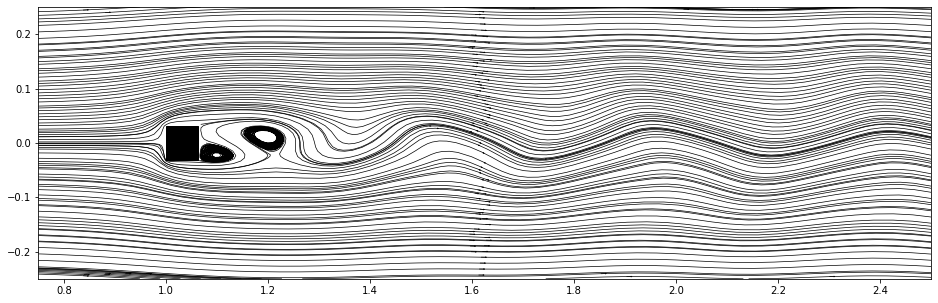

-1.3025989841591393e-08


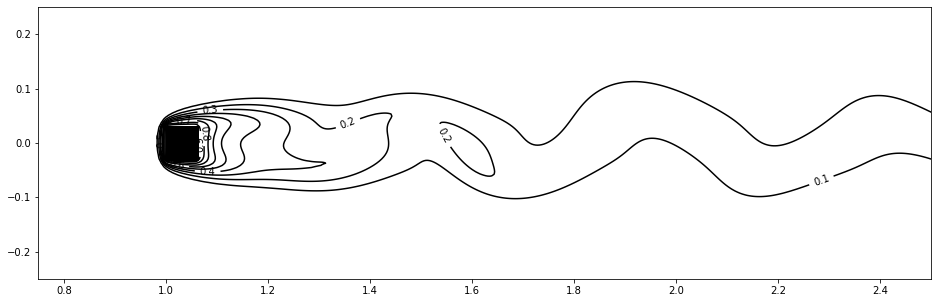

In [83]:
fig,ax=plt.subplots(1,1,figsize=(16,5))
plt.streamplot(xx_crop,yy_crop,U_crop,V_crop,density=1.5,color='k',arrowsize=0.2,linewidth=0.7,broken_streamlines=False)
plt.xlim(0.75,2.5)
plt.ylim(-H/4,H/4)

for n in range(n_squares):
    Nx_lft=int(square_coord[0][n])
    Nx_rgt=int(square_coord[1][n])
    Ny_top=int(square_coord[2][n])
    Ny_btm=int(square_coord[3][n])

    rect=patches.Rectangle([Nx_lft*dx,Ny_btm*dy-H/2],x_size*dx,y_size*dy,fc='k',ec='k')
    ax.add_patch(rect)
    
plt.show()
print(np.min(T_crop))

fig,ax=plt.subplots(1,1,figsize=(16,5))
graph=plt.contour(xx_crop,yy_crop,T_crop-np.min(T_crop),colors=['black'],levels=10,vmin=0,vmax=1)
plt.xlim(0.75,2.5)
plt.ylim(-H/4,H/4)

for n in range(n_squares):
    Nx_lft=int(square_coord[0][n])
    Nx_rgt=int(square_coord[1][n])
    Ny_top=int(square_coord[2][n])
    Ny_btm=int(square_coord[3][n])

    rect=patches.Rectangle([Nx_lft*dx,Ny_btm*dy-H/2],x_size*dx,y_size*dy,fc='k',ec='k')
    ax.add_patch(rect)
    
namelist=np.linspace(0,1,11)
    
plt.clabel(graph,namelist,inline=True)

plt.show()

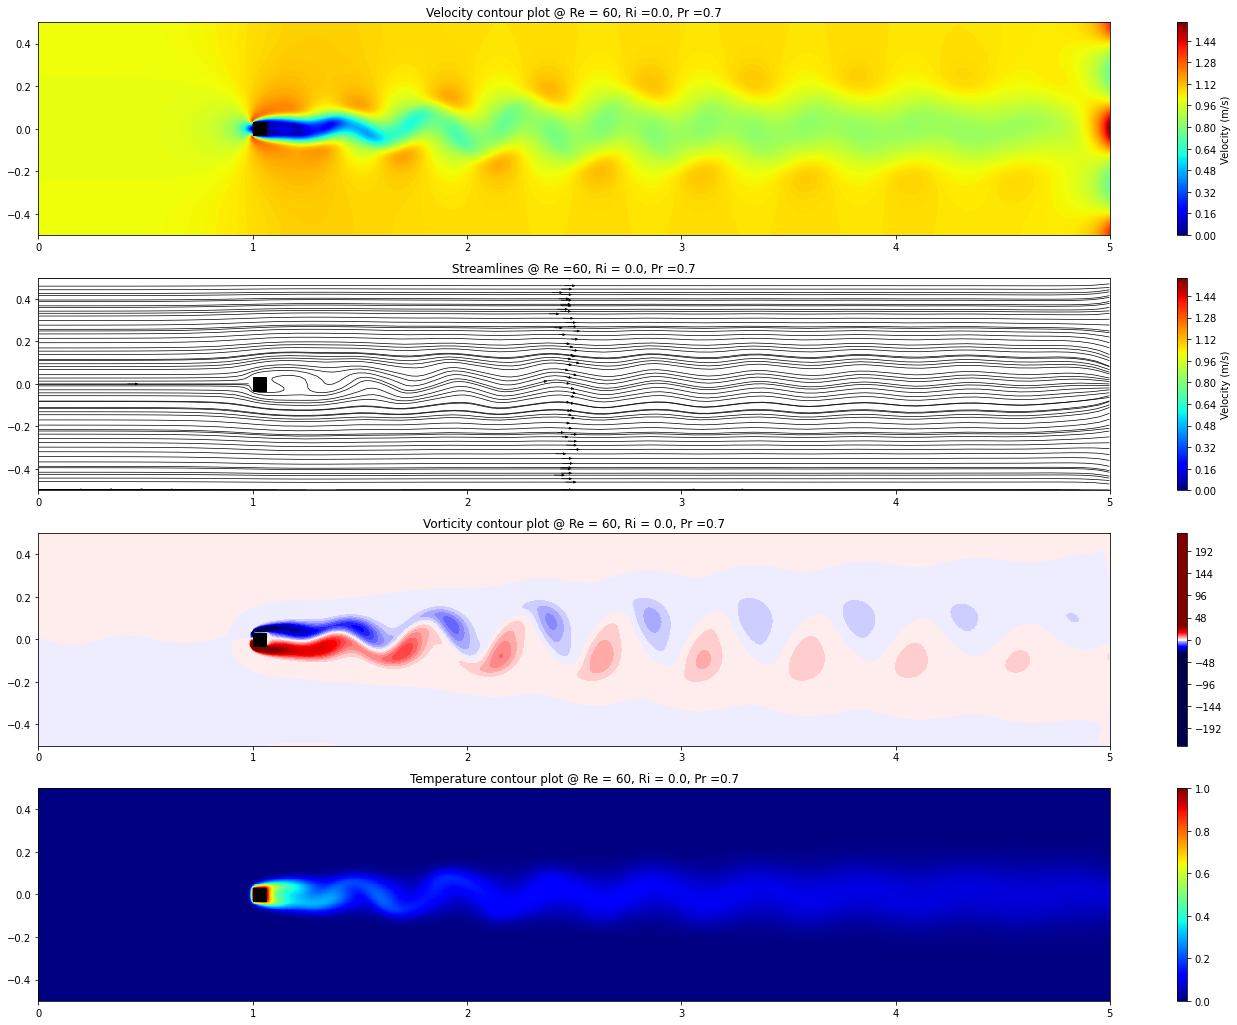

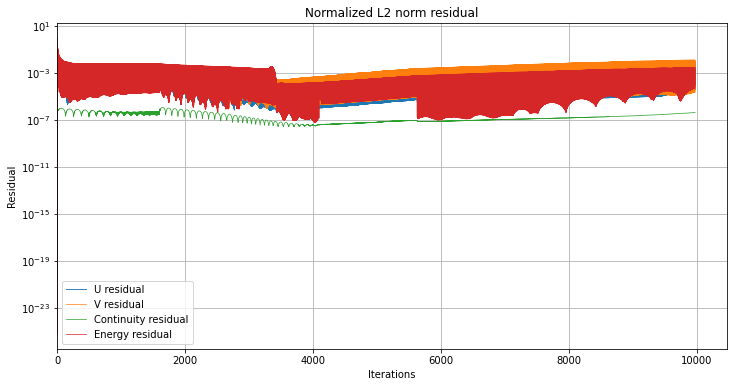

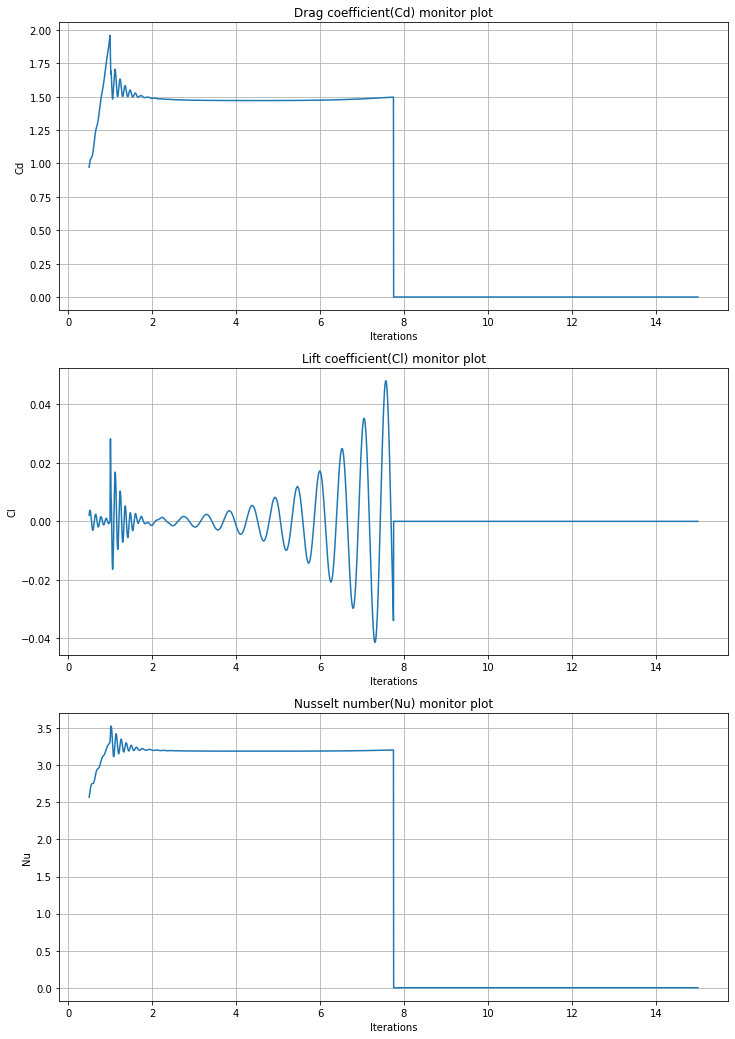

In [84]:
fig,ax=plt.subplots(4,1,figsize=(24,18)) 
graph=ax[0].contourf(xx,yy,V_mag,cmap=cm.jet,levels=255)
ax[0].set_title('Velocity contour plot @ Re = '+str(Re)+', Ri ='+str(Ri)+', Pr ='+str(Pr))
fig.colorbar(graph,ax=ax[0],label='Velocity (m/s)')
ax[0].set_xlim(0,L)
ax[0].set_ylim(-H/2,H/2)

ax[1].streamplot(xx,yy,U_final,V_final,density=1.25,linewidth=0.7,arrowsize=0.5,color='k',broken_streamlines=False)
ax[1].set_title('Streamlines @ Re ='+str(Re)+', Ri = '+str(Ri)+', Pr ='+str(Pr))
fig.colorbar(graph,ax=ax[1],label='Velocity (m/s)')
ax[1].set_xlim(0,L)
ax[1].set_ylim(-H/2,H/2)

graph=ax[2].contourf(xx,yy,vort,cmap=cm.seismic,levels=255,vmax=30*u_inlet,vmin=-30*u_inlet)
ax[2].set_title('Vorticity contour plot @ Re = '+str(Re)+', Ri = '+str(Ri)+', Pr ='+str(Pr))
fig.colorbar(graph,ax=ax[2])
ax[2].set_xlim(0,L)
ax[2].set_ylim(-H/2,H/2)

graph=ax[3].pcolormesh(xx,yy,T_final,cmap=cm.jet,vmax=T_square)
ax[3].set_title('Temperature contour plot @ Re = '+str(Re)+', Ri = '+str(Ri)+', Pr ='+str(Pr))
fig.colorbar(graph,ax=ax[3])
ax[3].set_xlim(0,L)
ax[3].set_ylim(-H/2,H/2)

for i in range(4):
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])
        
        rect=patches.Rectangle([Nx_lft*dx,Ny_btm*dy-H/2],x_size*dx,y_size*dy,fc='k',ec='k')
        ax[i].add_patch(rect)
    
plt.show()

iteration_eqn=np.linspace(0,len(U_res_list),len(U_res_list))
iterations=iteration_eqn
if Transient==True:
    iterations=np.linspace(0,len(cl_mean_array),len(cl_mean_array))
    iterations=iterations*dt
    
fig,ax=plt.subplots(1,1,figsize=(12,6))
plt.plot(iteration_eqn[:iter_total-2:],U_res_list[:iter_total-2:],label='U residual',linewidth=0.9)
plt.plot(iteration_eqn[:iter_total-2:],V_res_list[:iter_total-2:],label='V residual',linewidth=0.7)
plt.plot(iteration_eqn[:iter_total-2:],Cont_res_list[:iter_total-2:],label='Continuity residual',linewidth=0.7)
plt.plot(iteration_eqn[:iter_total-2:],T_res_list[:iter_total-2:],label='Energy residual',linewidth=0.7)
plt.xlabel('Iterations')
plt.ylabel('Residual')
plt.title('Normalized L2 norm residual')
ax.set_yscale('log')
plt.grid()
plt.xlim(0)
plt.legend()

plt.show()

fig,ax=plt.subplots(3,1,figsize=(12,18))
ax[0].plot(iterations[200:iter_total-1:],cd_mean_array[200:iter_total-1:])
ax[0].set_xlabel('Iterations')
ax[0].set_ylabel('Cd')
ax[0].set_title('Drag coefficient(Cd) monitor plot')
ax[0].grid()

ax[1].plot(iterations[200:iter_total-1:],cl_mean_array[200:iter_total-1:])
ax[1].set_xlabel('Iterations')
ax[1].set_ylabel('Cl')
ax[1].set_title('Lift coefficient(Cl) monitor plot')
ax[1].grid()

ax[2].plot(iterations[200:iter_total-1:],nu_mean_array[200:iter_total-1:])
ax[2].set_xlabel('Iterations')
ax[2].set_ylabel('Nu')
ax[2].set_title('Nusselt number(Nu) monitor plot')
ax[2].grid()

plt.show()

ValueError: x and y must have same first dimension, but have shapes (6000,) and (5470,)

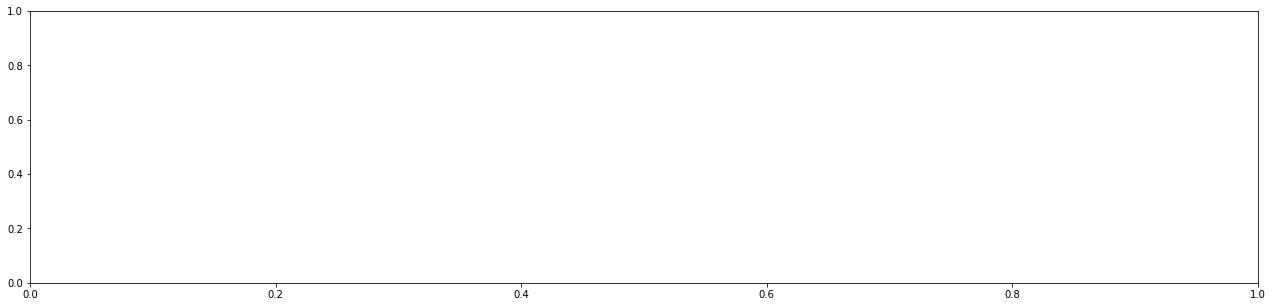

In [51]:
fig,ax=plt.subplots(1,1,figsize=(22,5))
for i in range(n_squares):
    plt.plot(iterations[::],cl_array[i][:iter_total:]-np.mean(cl_array[i][:iter_total:]),label='Square '+str(i+1))
    
x1=5.39
x2=12.61

plt.axvline(x1,color='k')
plt.axvline(x2,color='k')
plt.xlim(0)
plt.ylim(-0.15,0.15)
plt.xlabel('Flow time(s)')
plt.ylabel('Cl')
plt.title('Lift coefficient(Cl) vs time')
plt.grid()
plt.legend()
plt.show()

n=15
t=(x2-x1)/n
f=1/t
st=(n/(x2-x1))*Lc/u_inlet

print('Freq:',round(f,2),'Hz')
print('t   :',round(t,2),'s')
print("St  :",round(st,4))

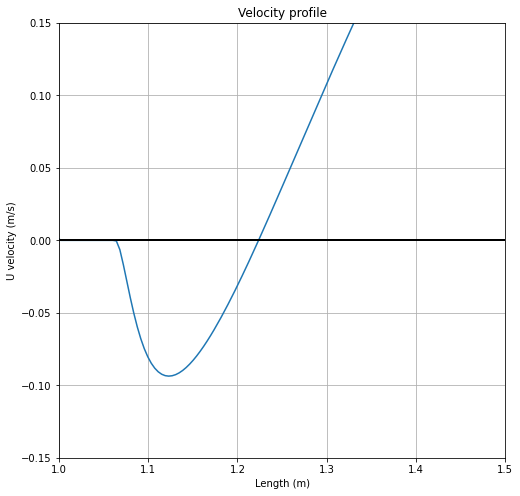

Expt: 2.5625


In [77]:
U_mid=(U_final[int(Ny/2)+1]+U_final[int(Ny/2)])/2

fig,ax=plt.subplots(1,1,figsize=(8,8))
plt.plot(x,U_mid)
plt.axhline(0,color='k',lw=2)
plt.title("Velocity profile")
plt.ylabel('U velocity (m/s)')
plt.xlabel('Length (m)')
plt.xlim(1,1.5)
plt.ylim(-0.15,0.15)
plt.grid()
plt.show()

for i in range(Nx_rgt,Nx):
    if U_mid[i]>0:
        break
grad=(U_mid[i]-U_mid[i-1])/dx
x_delta=U_mid[i]/grad
x0=float(x[i-1]+x_delta)-1.0625
x0=0.5*(x[i-1]+x[i])-1.0625

print('Expt:',round(x0/0.0625,4))

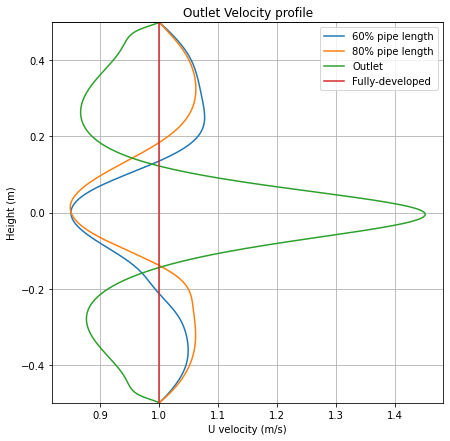

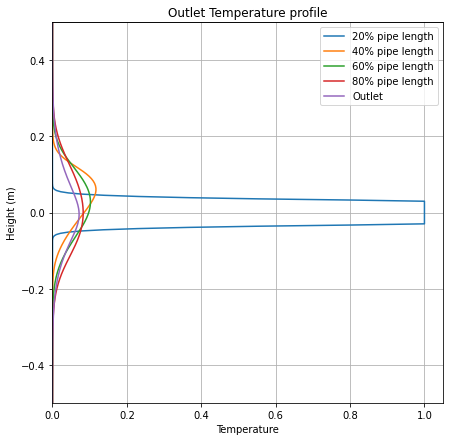

In [65]:
U_60=U_final[:,int(0.6*Nx)]
U_80=U_final[:,int(0.8*Nx)]
U_100=U_final[:,-1]

T_20=T_final[:,int(0.2*Nx)]
T_40=T_final[:,int(0.4*Nx)]
T_60=T_final[:,int(0.6*Nx)]
T_80=T_final[:,int(0.8*Nx)]
T_100=T_final[:,-1]

fig,ax=plt.subplots(1,1,figsize=(7,7))
plt.plot(U_60,y,label='60% pipe length')
plt.plot(U_80,y,label='80% pipe length')
plt.plot(U_100,y,label='Outlet')
plt.plot(u_inlet_array,y,label='Fully-developed')
plt.axhline(0.5,color='k')
plt.title("Outlet Velocity profile")
plt.xlabel('U velocity (m/s)')
plt.ylabel('Height (m)')
plt.ylim(-H/2,H/2)
plt.legend()
plt.grid()
plt.show()

fig,ax=plt.subplots(1,1,figsize=(7,7))
plt.plot(T_20,y,label='20% pipe length')
plt.plot(T_40,y,label='40% pipe length')
plt.plot(T_60,y,label='60% pipe length')
plt.plot(T_80,y,label='80% pipe length')
plt.plot(T_100,y,label='Outlet')
plt.axhline(0.5,color='k')
plt.title("Outlet Temperature profile")
plt.xlabel('Temperature')
plt.ylabel('Height (m)')
plt.xlim(0)
plt.ylim(-H/2,H/2)
plt.legend()
plt.grid()
plt.show()

In [90]:
len(U_data)

1500

In [91]:
U_anim=U_data[::]
V_anim=V_data[::]
T_anim=T_data[::]

count=len(U_data)

U_file=[]
V_file=[]
T_file=[]
V_mag_file=[]
Vort_file=[]
L_crop=10
for k in range(count):
    Ny_f=Ny
    Nx_f=Nx
    
    U_fine=U_anim[k]
    V_fine=V_anim[k]
    T_fine=T_anim[k]
    
#     x_crop=np.linspace(0,L_crop,int((L_crop/L)*Nx))
#     y_crop=np.linspace(0,H,Ny)
#     xx_crop,yy_crop=np.meshgrid(x_crop,y_crop)
    U_fine_crop=U_fine[0:Ny,0:int((L_crop/L)*Nx)]
    V_fine_crop=V_fine[0:Ny,0:int((L_crop/L)*Nx)]
    T_fine_crop=T_fine[0:Ny,0:int((L_crop/L)*Nx)]

#     V_mag_crop=V_mag[0:Ny,0:int((L_crop/L)*Nx)]
#     vort_crop=vort[0:Ny,0:int((L_crop/L)*Nx)]

#     for n in range(2):
#         Ny_c=int(Ny_f/2)
#         Nx_c=int(Nx_f/2)
        
#         U_coarse=nodal_restriction(U_fine,Ny_f,Nx_f,Ny_c,Nx_c)
#         V_coarse=nodal_restriction(V_fine,Ny_f,Nx_f,Ny_c,Nx_c)

#         U_fine=U_coarse
#         V_fine=V_coarse
        
#         Ny_f=Ny_c
#         Nx_f=Nx_c
            
    V_mag=np.sqrt(np.power(U_fine,2)+np.power(V_fine,2))           
    vort=curl(U_fine,V_fine,2*dx,2*dy,128,1280)
    V_mag_crop=V_mag[0:128,0:int((L_crop/L)*1280)]
    vort_crop=vort[0:128,0:int((L_crop/L)*1280)]
            
    U_file.append(U_fine_crop)
    V_file.append(V_fine_crop)
    V_mag_file.append(V_mag_crop)
    T_file.append(T_fine_crop)
    Vort_file.append(vort_crop)

In [92]:
U_file[0].shape

(128, 1280)

In [101]:
def animate(k):
    ax.clear()
    
    #U_final=U_file[k]
    #V_final=V_file[k]
    #T_final=T_file[k]
    vort=Vort_file[k]
    #V_mag=V_mag_file[k]
    plt.title('Flow time: '+str(round(k*dt*20,5))+' seconds')
    #plt.title('Streamlines')
    #plt.title('Flow time: '+str(round(k*dt*2,4))+' seconds')
    
    plt.xlim(0,L_crop)
    plt.ylim(0,H)
    
    #contour=plt.contourf(xx,yy,V_mag,cmap=cm.jet,vmax=2.5,levels=255)
    contour=plt.contourf(xx,yy,vort,cmap=cm.seismic,vmax=40,vmin=-40,levels=255)
    #contour=plt.contourf(xx,yy,T_final,cmap=cm.jet,vmax=1,vmin=0,levels=255)
    #stream=plt.streamplot(xx,yy,U_final,V_final,linewidth=0.8,density=1.25,color='k',arrowsize=0,broken_streamlines=False)
    
    for n in range(n_squares):
        Nx_lft=int(square_coord[0][n])
        Nx_rgt=int(square_coord[1][n])
        Ny_top=int(square_coord[2][n])
        Ny_btm=int(square_coord[3][n])

        rect=patches.Rectangle([Nx_lft*dx,Ny_btm*dy],x_size*dx,y_size*dy,fc='k',ec='k')
        ax.add_patch(rect)
    return contour

<IPython.core.display.Javascript object>


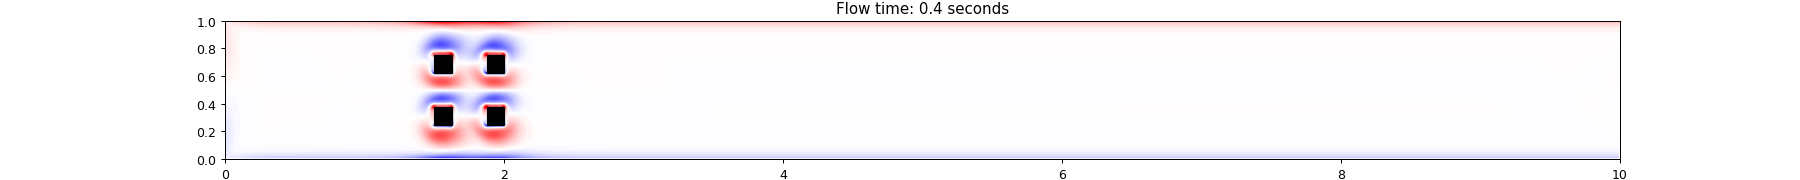

In [102]:
fig,ax=plt.subplots(1,1,figsize=(20,2))
plt.xlim(0,L)
plt.ylim(0,H)
x=np.linspace(0,L_crop,1280)
y=np.linspace(0,H,128)
xx,yy=np.meshgrid(x,y)

ani=FuncAnimation(fig,animate,count,interval=500, blit=True)
plt.show()